# 04 — Exploratory Data Analysis (EDA)

## Mục tiêu
1. Phân phối Target (gia_ban, log_gia_ban)
2. Phân phối các Feature chính
3. Phân tích vị trí: Quận & Phường
4. Phân tích Categorical Features vs Giá
5. Phân tích Text Features mới (trích từ tieu_de + mo_ta)
6. Phân tích bieu_do_gia features
7. Scatter Plots — mối quan hệ Feature ↔ Giá
8. Correlation Heatmap & Multicollinearity
9. Phát hiện Outlier (IQR)
10. Missing Values
10A. Violin Plot — Quận × Loại hình
10B. Tiện nghi Score vs Giá
10C. Feature Interaction — Text Features theo Quận
10D. Phân khúc Giá (Price Segmentation)
10E. Pairplot — Top Features
11. Tổng hợp Insights → chuẩn bị Modeling

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

df = pd.read_parquet('../data/processed/data_modeling.parquet')

# Tạo lại gia_ban từ log_gia_ban (đã bị drop ở notebook 03)
if "gia_ban" not in df.columns and "log_gia_ban" in df.columns:
    df["gia_ban"] = np.exp(df["log_gia_ban"])
    print("✅ Tạo lại gia_ban = exp(log_gia_ban)")

print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Numeric: {df.select_dtypes(include='number').shape[1]} | Categorical: {df.select_dtypes(include='object').shape[1]}")

Dataset: 6979 rows × 29 columns
Numeric: 25 | Categorical: 4


## 1. Phân phối Target Variable

In [2]:
if "gia_ban" not in df.columns and "log_gia_ban" in df.columns:
    df["gia_ban"] = np.exp(df["log_gia_ban"])

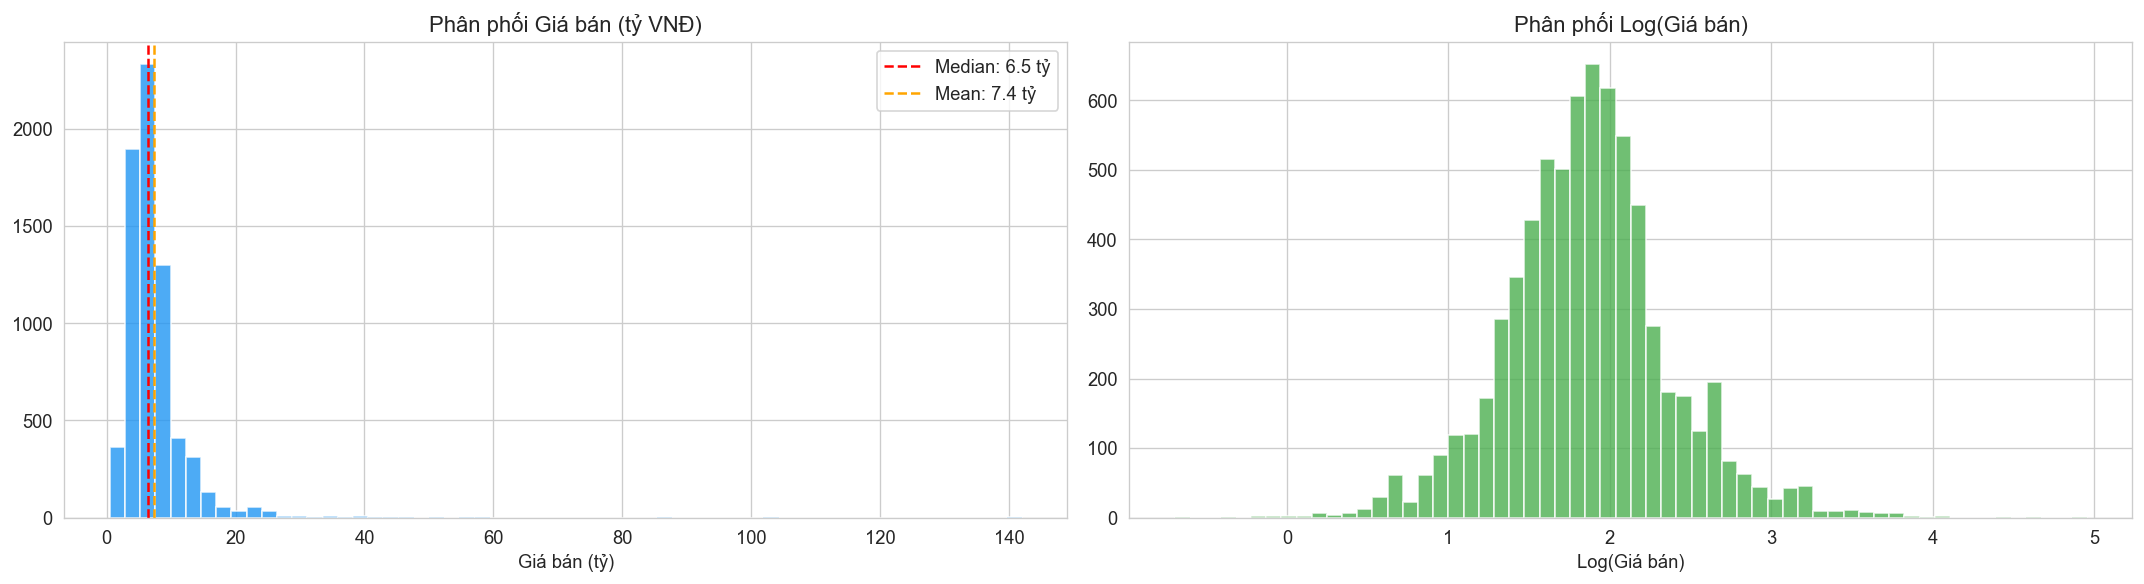

Skewness  — gia_ban: 6.49 | log_gia_ban: 0.26
Kurtosis  — gia_ban: 104.90 | log_gia_ban: 1.59

gia_ban: mean=7.42, median=6.48, std=5.12


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].hist(df["gia_ban"].dropna(), bins=60, color="#2196F3", edgecolor="white", alpha=0.8)
axes[0].axvline(df["gia_ban"].median(), color="red", linestyle="--", label=f'Median: {df["gia_ban"].median():.1f} tỷ')
axes[0].axvline(df["gia_ban"].mean(), color="orange", linestyle="--", label=f'Mean: {df["gia_ban"].mean():.1f} tỷ')
axes[0].set_title("Phân phối Giá bán (tỷ VNĐ)")
axes[0].set_xlabel("Giá bán (tỷ)")
axes[0].legend()

axes[1].hist(df["log_gia_ban"].dropna(), bins=60, color="#4CAF50", edgecolor="white", alpha=0.8)
axes[1].set_title("Phân phối Log(Giá bán)")
axes[1].set_xlabel("Log(Giá bán)")

# axes[2].hist(df["gia_m2"].dropna(), bins=60, color="#FF9800", edgecolor="white", alpha=0.8)
# axes[2].axvline(df["gia_m2"].median(), color="red", linestyle="--", label=f'Median: {df["gia_m2"].median():.0f} tr/m²')
# axes[2].set_title("Phân phối Đơn giá (triệu/m²)")
# axes[2].set_xlabel("Giá/m² (triệu)")
# axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Skewness  — gia_ban: {df['gia_ban'].skew():.2f} | log_gia_ban: {df['log_gia_ban'].skew():.2f}")
print(f"Kurtosis  — gia_ban: {df['gia_ban'].kurtosis():.2f} | log_gia_ban: {df['log_gia_ban'].kurtosis():.2f}")
print(f"\ngia_ban: mean={df['gia_ban'].mean():.2f}, median={df['gia_ban'].median():.2f}, std={df['gia_ban'].std():.2f}")

**Nhận xét:**
- `gia_ban` lệch phải mạnh (right-skewed): skewness = 6.49, kurtosis = 104.90
- Mean = 7.42 tỷ, median = 6.48 tỷ, std = 5.12 tỷ
- `log_gia_ban` gần chuẩn hơn: skewness = 0.26, kurtosis = 1.59
- → Sử dụng `log_gia_ban` làm target cho mô hình regression


## 2. Phân phối Feature chính

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6979 entries, 0 to 6978
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   giay_to_phap_ly    6979 non-null   object 
 1   dien_tich          6979 non-null   float64
 2   gia_ban            6979 non-null   float64
 3   loai_hinh          6979 non-null   object 
 4   so_phong_ngu       6979 non-null   int64  
 5   quan               6979 non-null   object 
 6   gia_kv_hien_tai    6979 non-null   float64
 7   gia_kv_mean        6979 non-null   float64
 8   gia_kv_trend       6979 non-null   float64
 9   gia_kv_volatility  6979 non-null   float64
 10  full_text          6979 non-null   object 
 11  is_mat_tien        6979 non-null   int64  
 12  is_hxh             6979 non-null   int64  
 13  is_lo_goc          6979 non-null   int64  
 14  is_kinh_doanh      6979 non-null   int64  
 15  is_dong_tien       6979 non-null   int64  
 16  is_no_hau          6979 

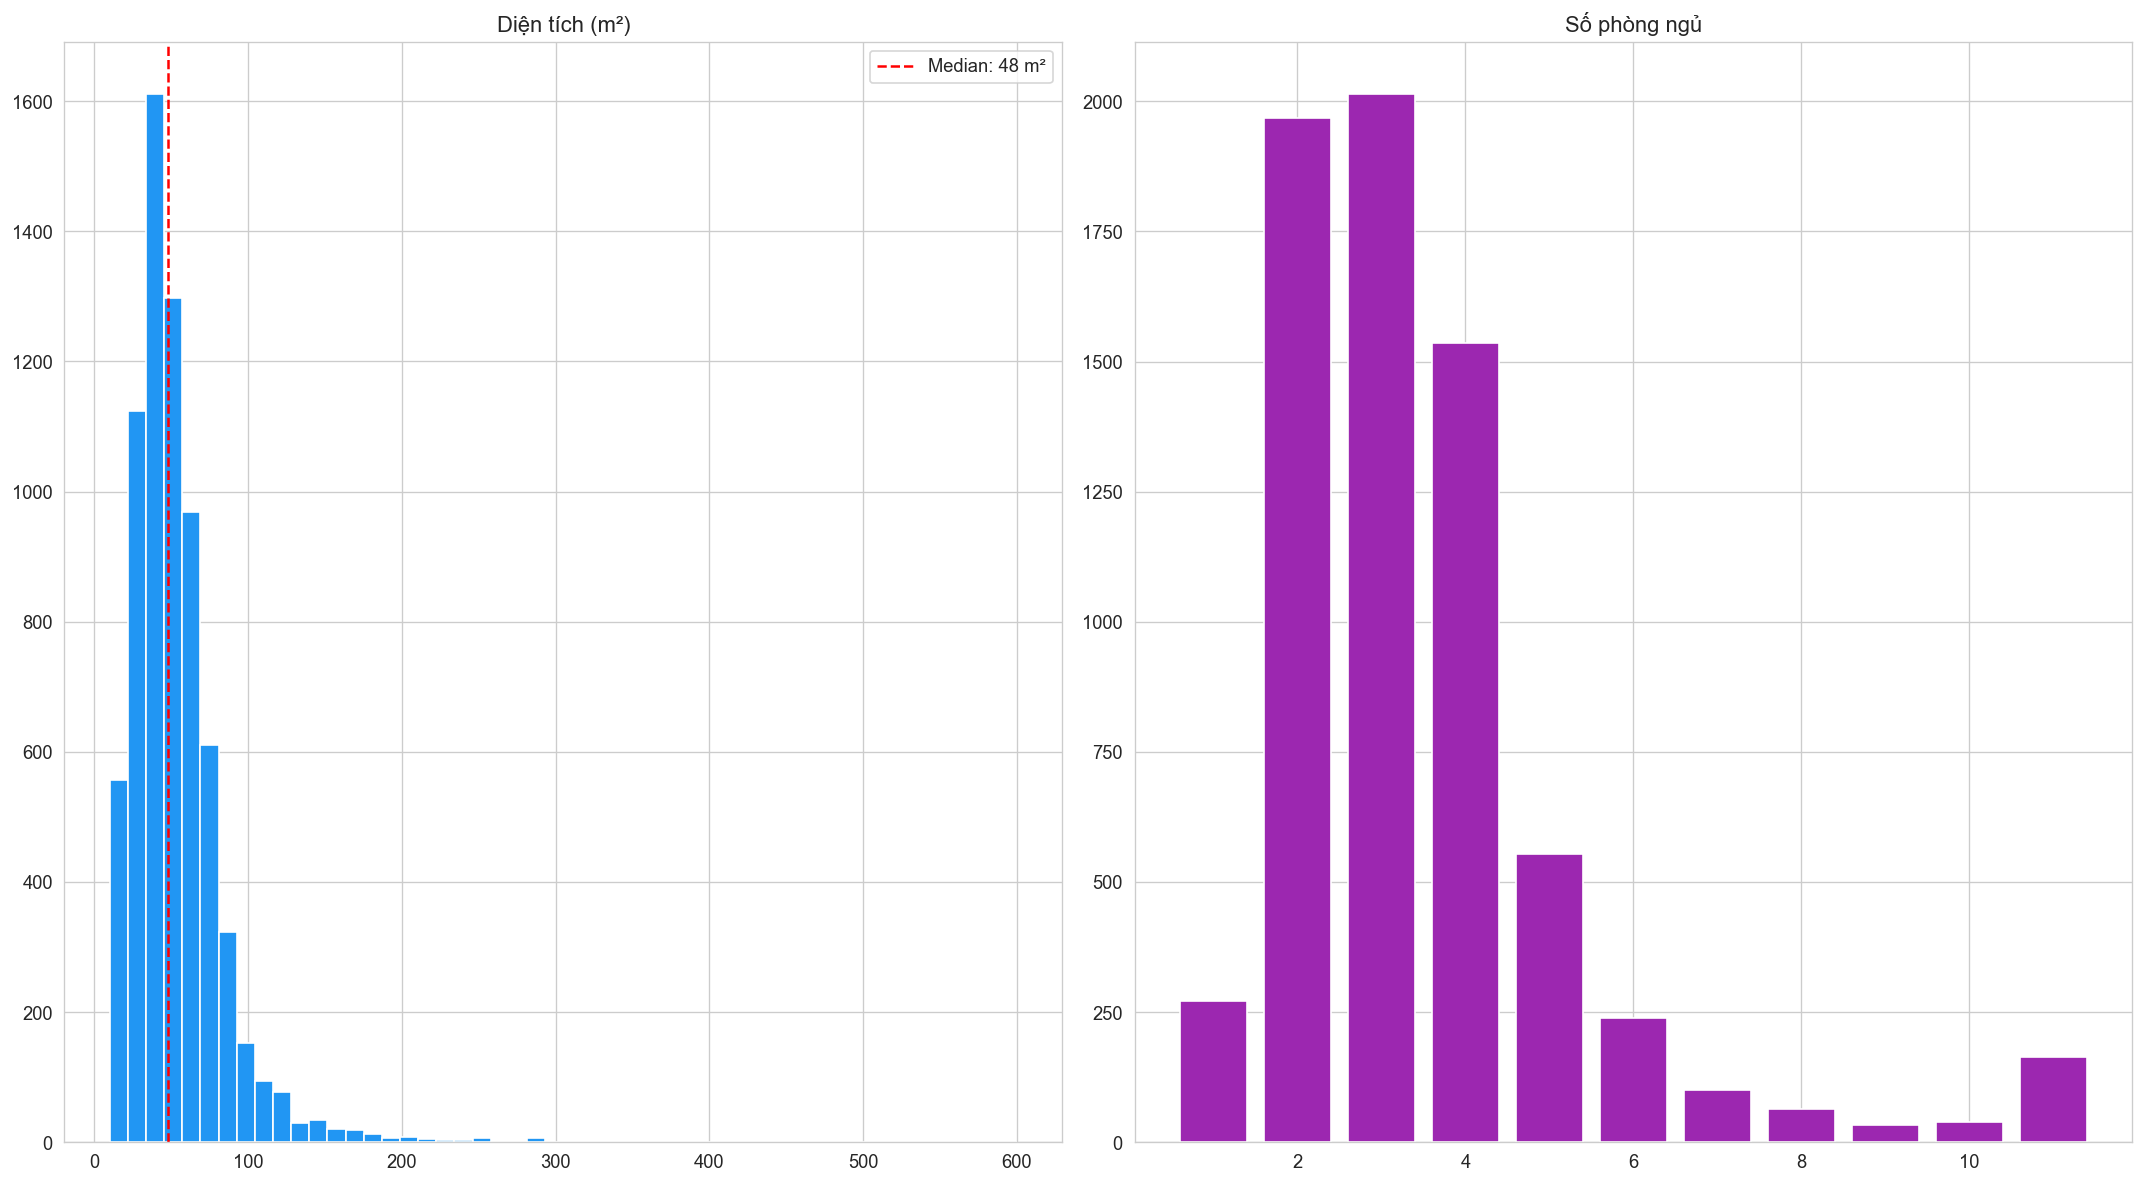

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

axes[0].hist(df["dien_tich"].dropna(), bins=50, color="#2196F3", edgecolor="white")
axes[0].axvline(df["dien_tich"].median(), color="red", linestyle="--",
                   label=f'Median: {df["dien_tich"].median():.0f} m²')
axes[0].set_title("Diện tích (m²)")
axes[0].legend()

sn = df["so_phong_ngu"].dropna()
axes[1].bar(sn.value_counts().sort_index().index, sn.value_counts().sort_index().values,
              color="#9C27B0", edgecolor="white")
axes[1].set_title("Số phòng ngủ")

plt.tight_layout()
plt.show()

**Nhận xét:**
- Diện tích: median ~49 m², đa số 20–80 m² → nhà hẻm TP.HCM.
- Chiều ngang tập trung 3–5m → nhà ống chiếm đa số.
- 3 phòng ngủ phổ biến nhất, 3–4 tầng là chủ đạo.
- Aspect ratio 2–4 → xác nhận dạng nhà ống (dài gấp 2–4 lần ngang).

## 3. Phân tích theo Quận

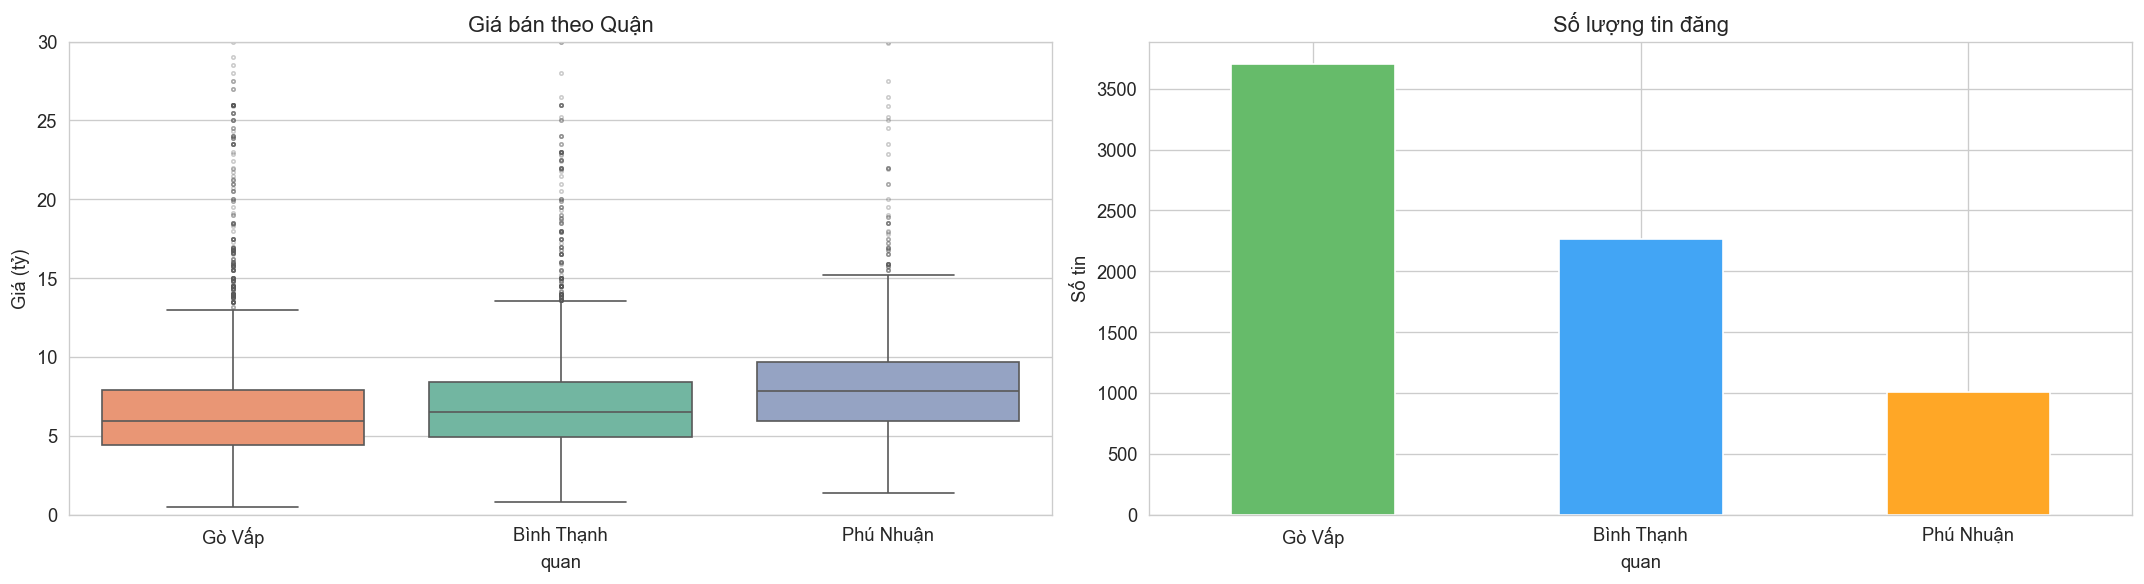

Thống kê theo Quận:
            count  median_gia  mean_gia  median_dt
quan                                              
Gò Vấp       3702        5.95  6.965041       50.0
Bình Thạnh   2268        6.50  7.668896       46.0
Phú Nhuận    1009        7.85  8.535295       40.5


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

order = df.groupby("quan")["gia_ban"].median().sort_values().index

sns.boxplot(x="quan", y="gia_ban", hue="quan", data=df, order=order,
            ax=axes[0], palette="Set2", legend=False,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[0].set_title("Giá bán theo Quận")
axes[0].set_ylabel("Giá (tỷ)")
axes[0].set_ylim(0, 30)

df["quan"].value_counts().reindex(order).plot.bar(
    ax=axes[1], color=["#66BB6A","#42A5F5","#FFA726"])
axes[1].set_title("Số lượng tin đăng")
axes[1].set_ylabel("Số tin")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("Thống kê theo Quận:")
print(df.groupby("quan").agg(
    count=("gia_ban","count"),
    median_gia=("gia_ban","median"),
    mean_gia=("gia_ban","mean"),
    median_dt=("dien_tich","median")
).sort_values("median_gia").to_string())

**Nhận xét:**
- **Gò Vấp**: 3,702 tin (53%), median 5.95 tỷ — rẻ nhất
- **Bình Thạnh**: 2,268 tin (32.5%), median 6.50 tỷ
- **Phú Nhuận**: 1,009 tin (14.5%), median 7.85 tỷ — đắt nhất
- Gò Vấp chiếm >50% → cần lưu ý khi đánh giá model


## 4. Phân tích Categorical Features vs Giá

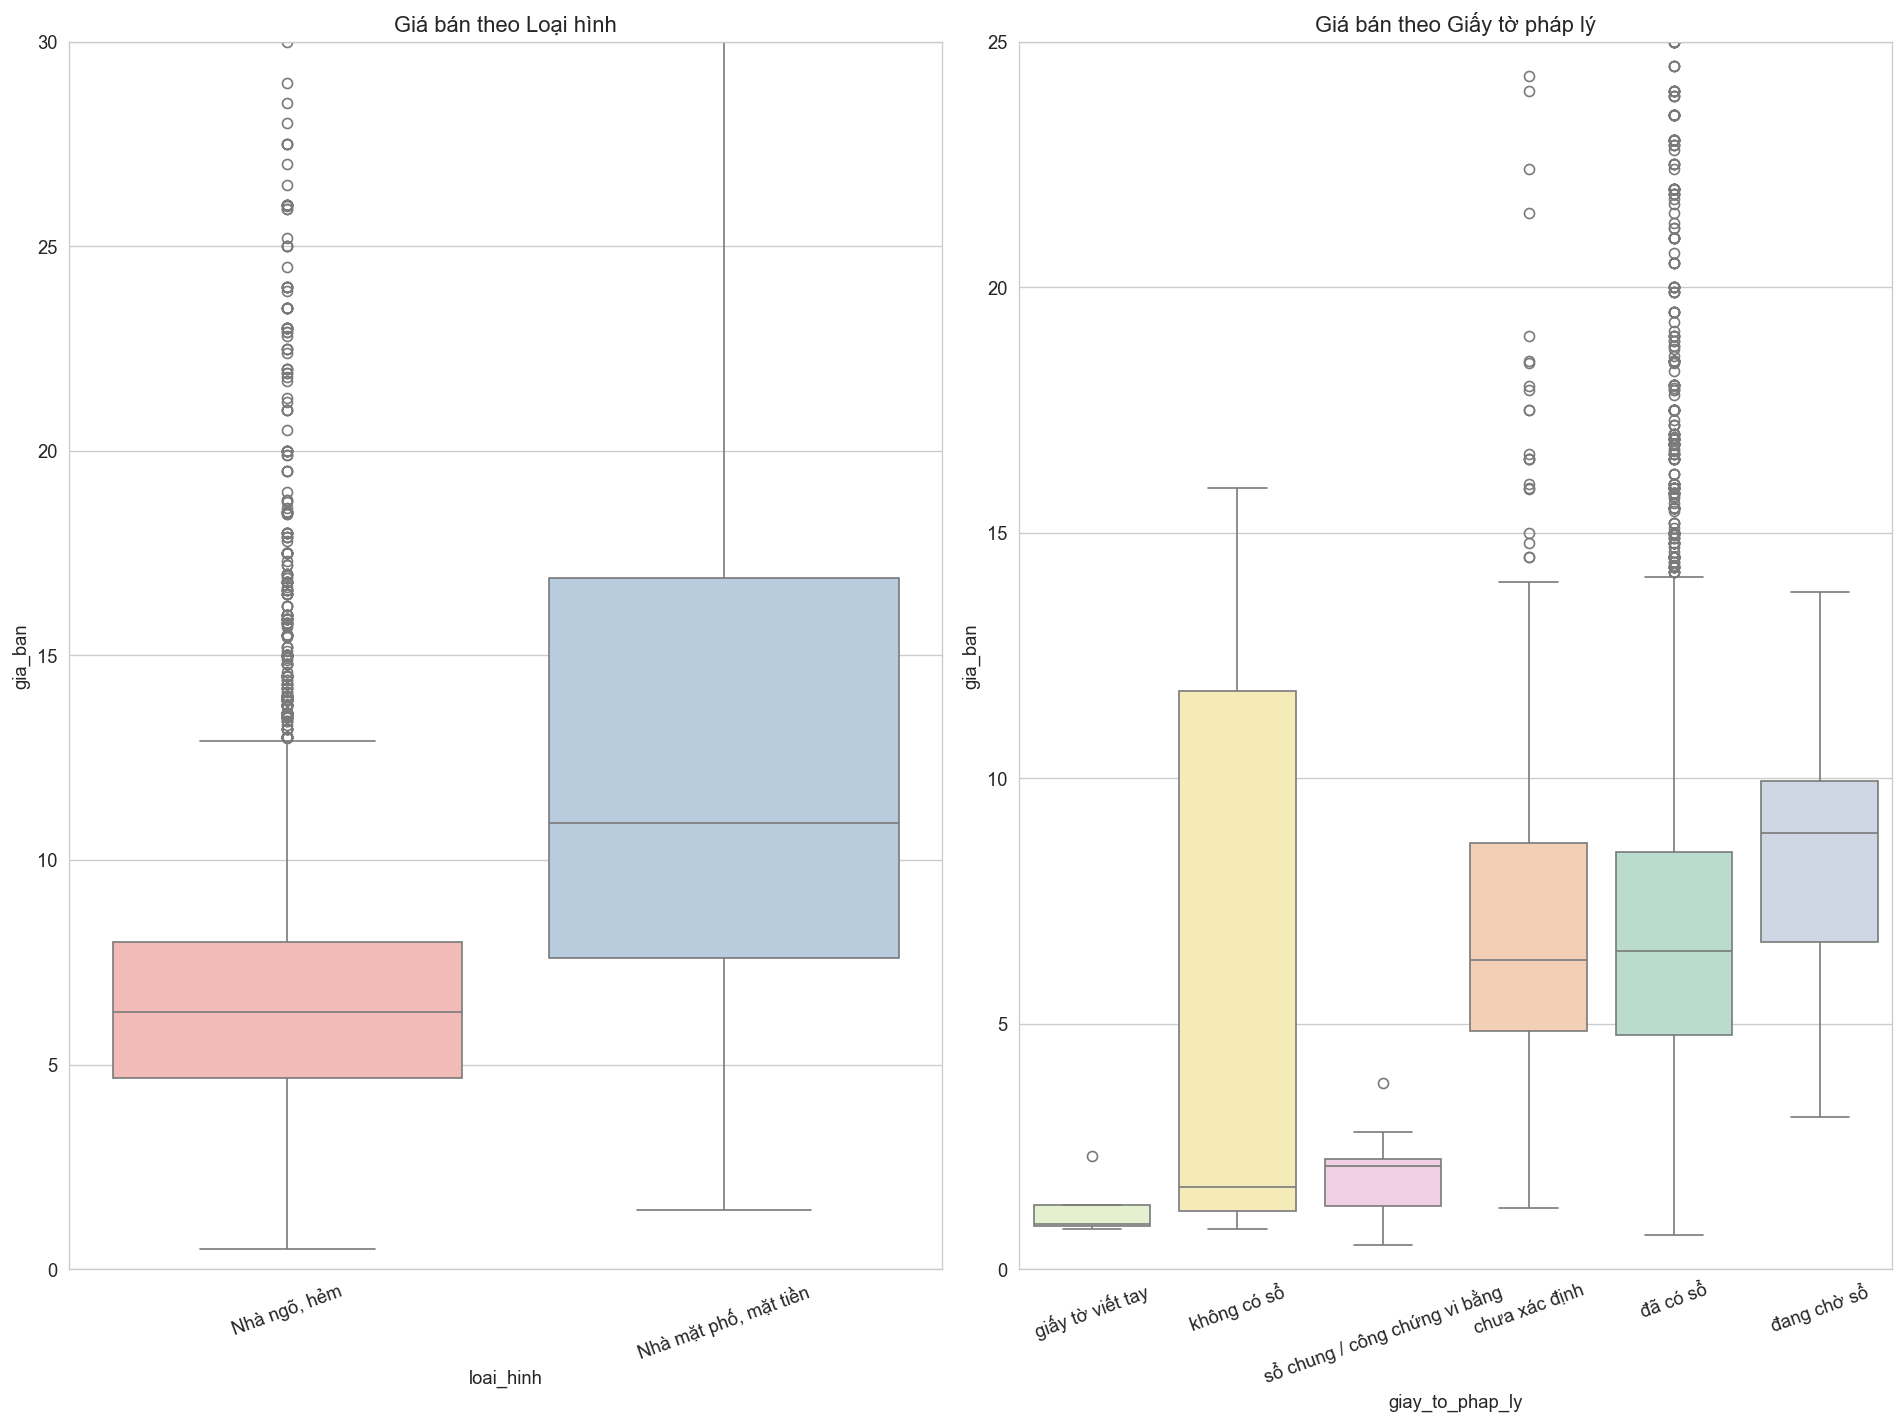

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 12))

# Loại hình
loai_order = df.groupby("loai_hinh")["gia_ban"].median().sort_values().index
sns.boxplot(x="loai_hinh", y="gia_ban", hue="loai_hinh", data=df, order=loai_order,
            ax=axes[0], palette="Pastel1", legend=False)
axes[0].set_title("Giá bán theo Loại hình")
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylim(0, 30)

# Giấy tờ pháp lý
gt = df[df["giay_to_phap_ly"].notna()]
gt_order = gt.groupby("giay_to_phap_ly")["gia_ban"].median().sort_values().index
sns.boxplot(x="giay_to_phap_ly", y="gia_ban", hue="giay_to_phap_ly", data=gt, order=gt_order,
            ax=axes[1], palette="Pastel2", legend=False)
axes[1].set_title("Giá bán theo Giấy tờ pháp lý")
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylim(0, 25)

plt.tight_layout()
plt.show()

**Nhận xét:**
- **Biệt thự** và **mặt phố** đắt hơn rõ rệt so với nhà hẻm.
- "Đã có sổ" chiếm đại đa số — các loại pháp lý khác quá ít mẫu.
- "Nội thất cao cấp" chênh nhẹ so với "cơ bản" — gợi ý rằng vị trí/diện tích quan trọng hơn nội thất.

## 5. Phân tích Text Features mới (trích từ tieu_de + mo_ta)

Đây là nhóm features mới được tạo ở notebook 03_2 bằng regex trên `full_text = tieu_de + mo_ta`.
Kiểm tra xem chúng thực sự có ảnh hưởng đến giá không.


In [8]:
# Tính median giá cho từng text feature ON vs OFF
text_features = ['is_mat_tien', 'is_hxh', 'is_lo_goc', 'is_kinh_doanh', 'is_dong_tien',
                 'is_no_hau', 'has_thang_may', 'is_nha_moi', 'is_nha_nat', 'has_quy_hoach',
                 'is_chinh_chu', 'has_san_thuong', 'has_gara', 'o_ngay',
                 'is_ngop_bank', 'is_ban_gap']

# Chỉ lấy features thực sự tồn tại trong df
text_features = [f for f in text_features if f in df.columns]

results = []
for feat in text_features:
    n_on = df[feat].sum()
    pct = n_on / len(df) * 100
    med_off = df.loc[df[feat]==0, "gia_ban"].median()
    med_on = df.loc[df[feat]==1, "gia_ban"].median()
    corr = df[[feat, "log_gia_ban"]].dropna().corr().iloc[0,1]
    results.append({"Feature": feat, "Count": int(n_on), "Pct": f"{pct:.1f}%",
                    "Median_OFF": f"{med_off:.1f}", "Median_ON": f"{med_on:.1f}",
                    "Delta": f"{med_on - med_off:+.1f}", "Corr_logP": f"{corr:+.3f}"})

results_df = pd.DataFrame(results).sort_values("Corr_logP", key=lambda x: x.str.replace("+","").astype(float), ascending=False)
print(results_df.to_string(index=False))

       Feature  Count   Pct Median_OFF Median_ON Delta Corr_logP
 has_thang_may    221  3.2%        6.3      13.8  +7.5    +0.279
has_san_thuong   2017 28.9%        5.8       7.6  +1.8    +0.243
  is_dong_tien   1820 26.1%        6.0       7.6  +1.6    +0.239
 is_kinh_doanh    991 14.2%        6.1       8.0  +1.9    +0.220
   is_mat_tien   2435 34.9%        6.0       7.0  +1.0    +0.166
      has_gara    578  8.3%        6.2       8.0  +1.8    +0.157
     is_lo_goc    468  6.7%        6.4       7.3  +0.9    +0.091
        is_hxh   3063 43.9%        6.0       6.8  +0.8    +0.075
    is_nha_nat    216  3.1%        6.4       7.5  +1.1    +0.075
    is_ban_gap    575  8.2%        6.4       7.5  +1.1    +0.070
     is_no_hau   1029 14.7%        6.4       6.8  +0.4    +0.061
  is_ngop_bank    542  7.8%        6.4       7.2  +0.8    +0.044
  is_chinh_chu   1802 25.8%        6.4       6.7  +0.3    +0.039
 has_quy_hoach    586  8.4%        6.5       6.5  +0.0    -0.003
    is_nha_moi   2234 32.

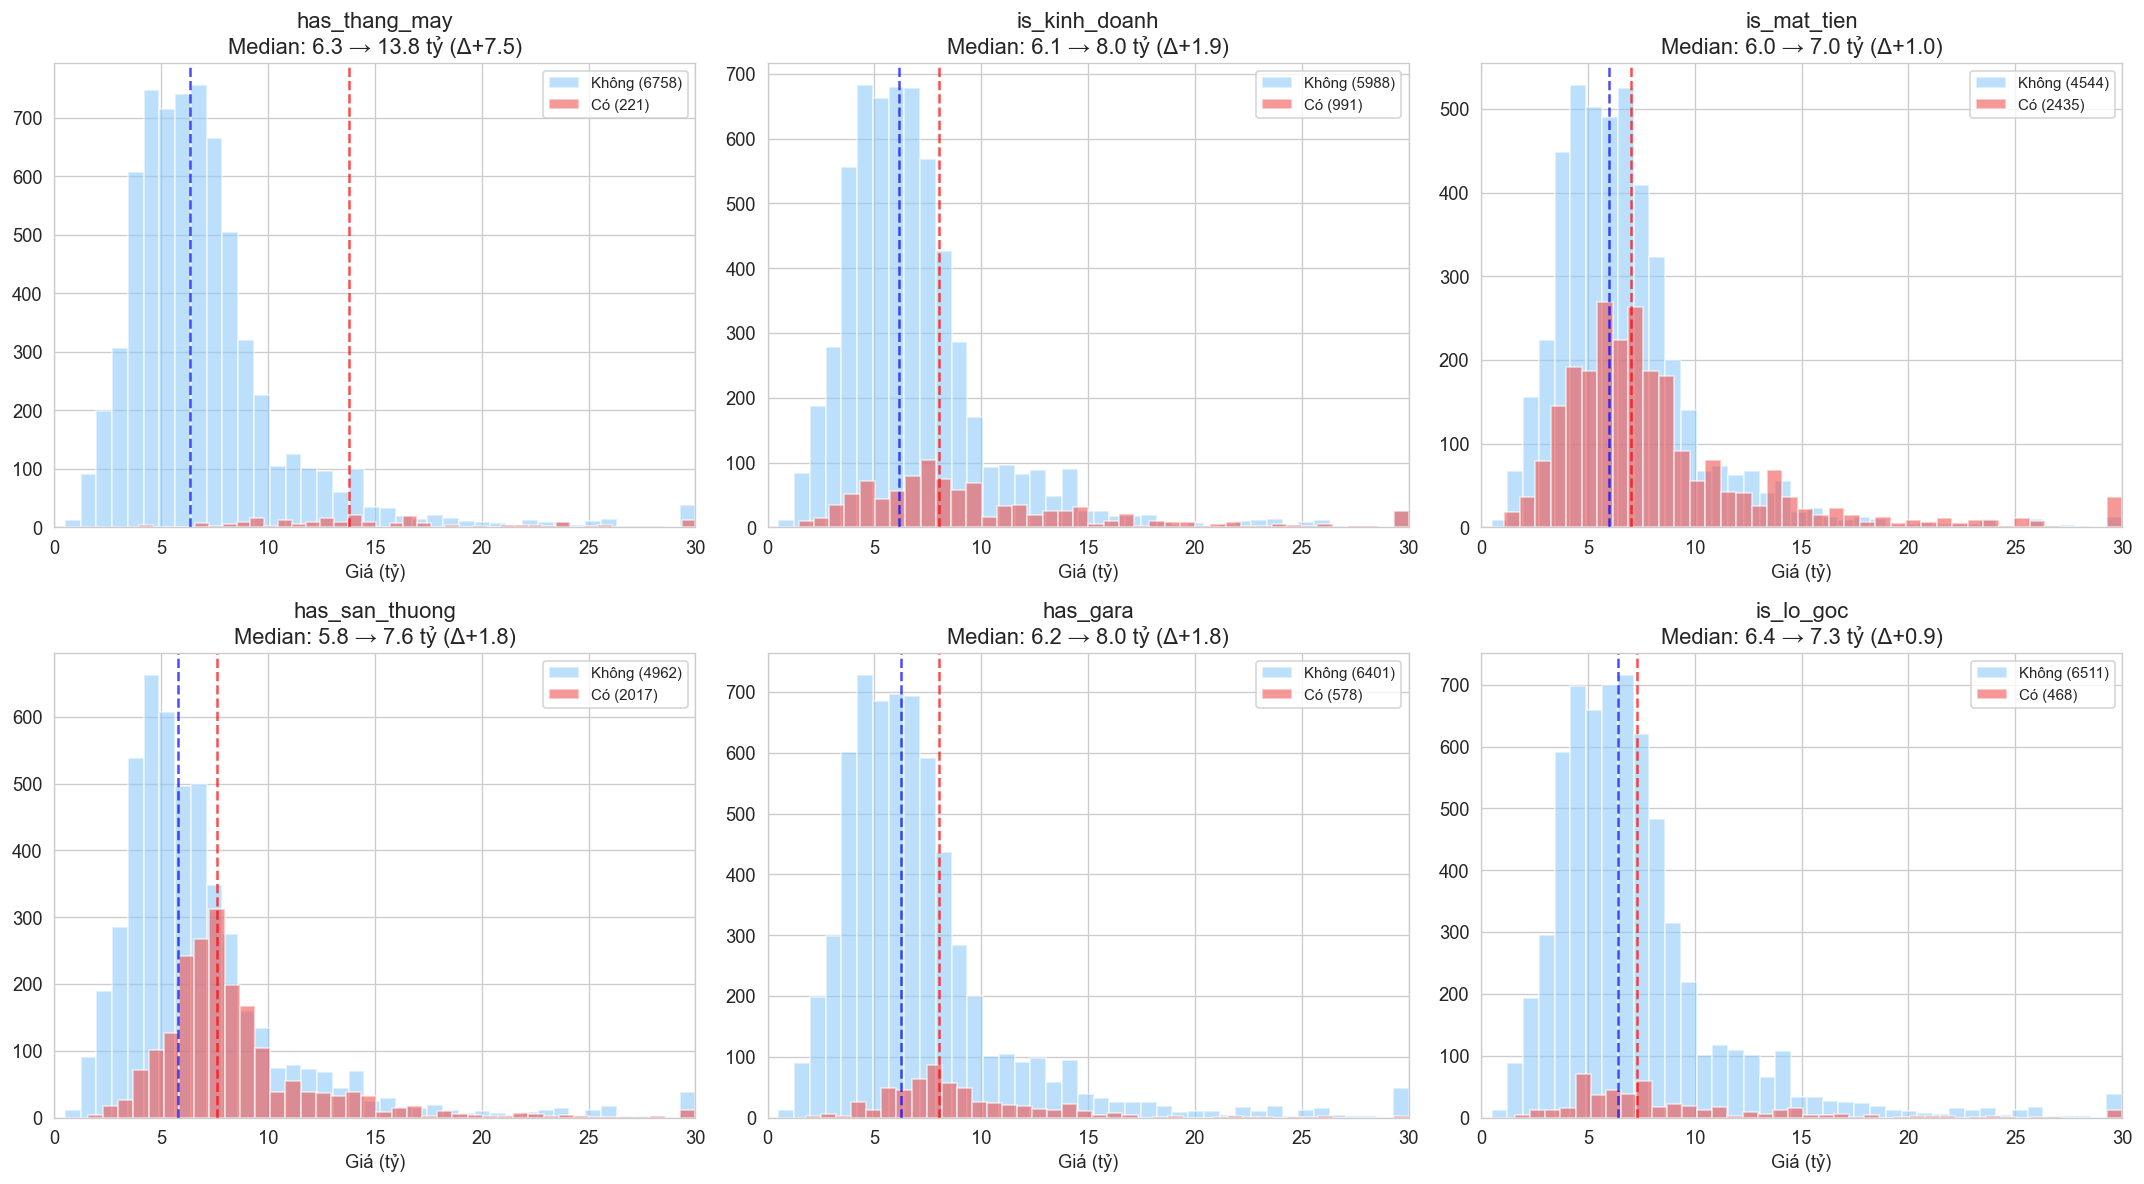

In [9]:
# Visualize top text features impact
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

top_text = ['has_thang_may', 'is_kinh_doanh', 'is_mat_tien', 'has_san_thuong', 'has_gara', 'is_lo_goc']
top_text = [f for f in top_text if f in df.columns]

for ax, feat in zip(axes.flat, top_text):
    data_0 = df.loc[df[feat]==0, "gia_ban"].dropna()
    data_1 = df.loc[df[feat]==1, "gia_ban"].dropna()
    ax.hist(data_0.clip(0,30), bins=40, alpha=0.6, label=f"Không ({len(data_0)})", color="#90CAF9")
    ax.hist(data_1.clip(0,30), bins=40, alpha=0.6, label=f"Có ({len(data_1)})", color="#EF5350")
    ax.axvline(data_0.median(), color="blue", linestyle="--", alpha=0.7)
    ax.axvline(data_1.median(), color="red", linestyle="--", alpha=0.7)
    ax.set_title(f"{feat}\nMedian: {data_0.median():.1f} → {data_1.median():.1f} tỷ (Δ{data_1.median()-data_0.median():+.1f})")
    ax.set_xlabel("Giá (tỷ)")
    ax.legend(fontsize=9)
    ax.set_xlim(0, 30)

# Fill remaining axes if less than 6 features
for j in range(len(top_text), 6):
    axes.flat[j].set_visible(False)

plt.tight_layout()
plt.show()

**Nhận xét:**
- **`has_thang_may`**: impact lớn nhất (+7.5 tỷ, corr = +0.279) — thang máy = nhà cao cấp
- **`has_san_thuong`**: +1.8 tỷ, 28.9% (corr = +0.243)
- **`is_dong_tien`**: +1.6 tỷ, 26.1% (corr = +0.239)
- **`is_kinh_doanh`**: +1.9 tỷ, 14.2% (corr = +0.220)
- **`is_mat_tien`**: +1.0 tỷ, 34.9% (corr = +0.166)

→ Thang máy tạo chênh lệch giá lớn nhất trong nhóm text features.


## 6. Phân tích `bieu_do_gia` Features (giá khu vực)


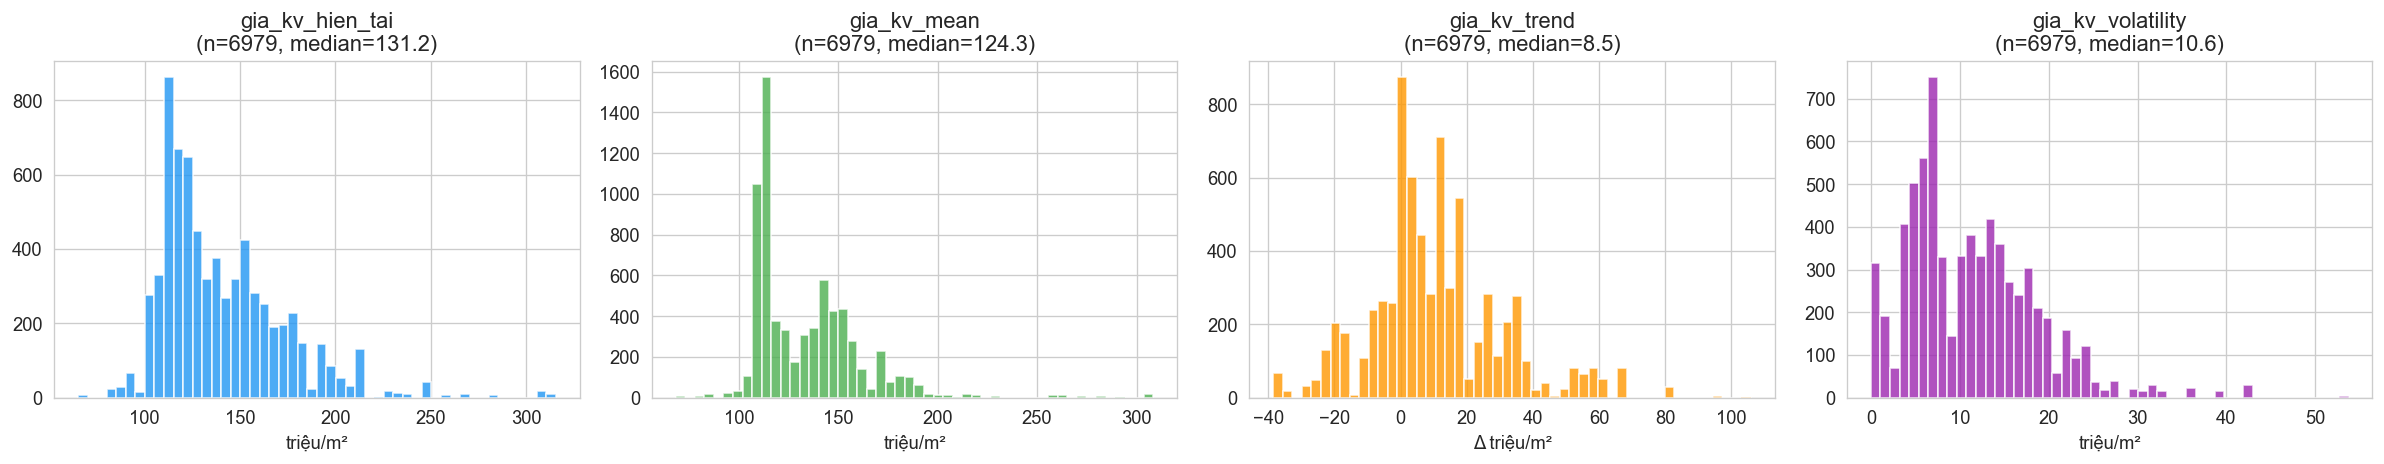

Correlation giá khu vực → log_gia_ban:
  gia_kv_hien_tai          : +0.237
  gia_kv_mean              : +0.277
  gia_kv_trend             : +0.017
  gia_kv_volatility        : +0.055


In [10]:
gia_kv_cols = [c for c in ['gia_kv_hien_tai', 'gia_kv_mean', 'gia_kv_trend', 'gia_kv_volatility'] if c in df.columns]

if gia_kv_cols:
    fig, axes = plt.subplots(1, len(gia_kv_cols), figsize=(5*len(gia_kv_cols), 4))
    if len(gia_kv_cols) == 1:
        axes = [axes]

    colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]
    for ax, col, color in zip(axes, gia_kv_cols, colors):
        data = df[col].dropna()
        ax.hist(data, bins=50, color=color, edgecolor="white", alpha=0.8)
        ax.set_title(f"{col}\n(n={len(data)}, median={data.median():.1f})")
        ax.set_xlabel("triệu/m²" if "trend" not in col else "Δ triệu/m²")

    plt.tight_layout()
    plt.show()

    # Correlation with target
    print("Correlation giá khu vực → log_gia_ban:")
    for col in gia_kv_cols:
        c = df[[col, "log_gia_ban"]].dropna().corr().iloc[0,1]
        print(f"  {col:25s}: {c:+.3f}")
else:
    print("Không tìm thấy gia_kv columns trong df")

**Nhận xét:**
- `gia_kv_mean`: corr = +0.277 → feature hữu ích, KHÔNG leakage
- `gia_kv_hien_tai`: corr = +0.237
- `gia_kv_volatility`: corr = +0.055 → ít ảnh hưởng
- `gia_kv_trend`: corr = +0.017 → gần như không tương quan


## 7. Scatter Plots — Feature vs Giá


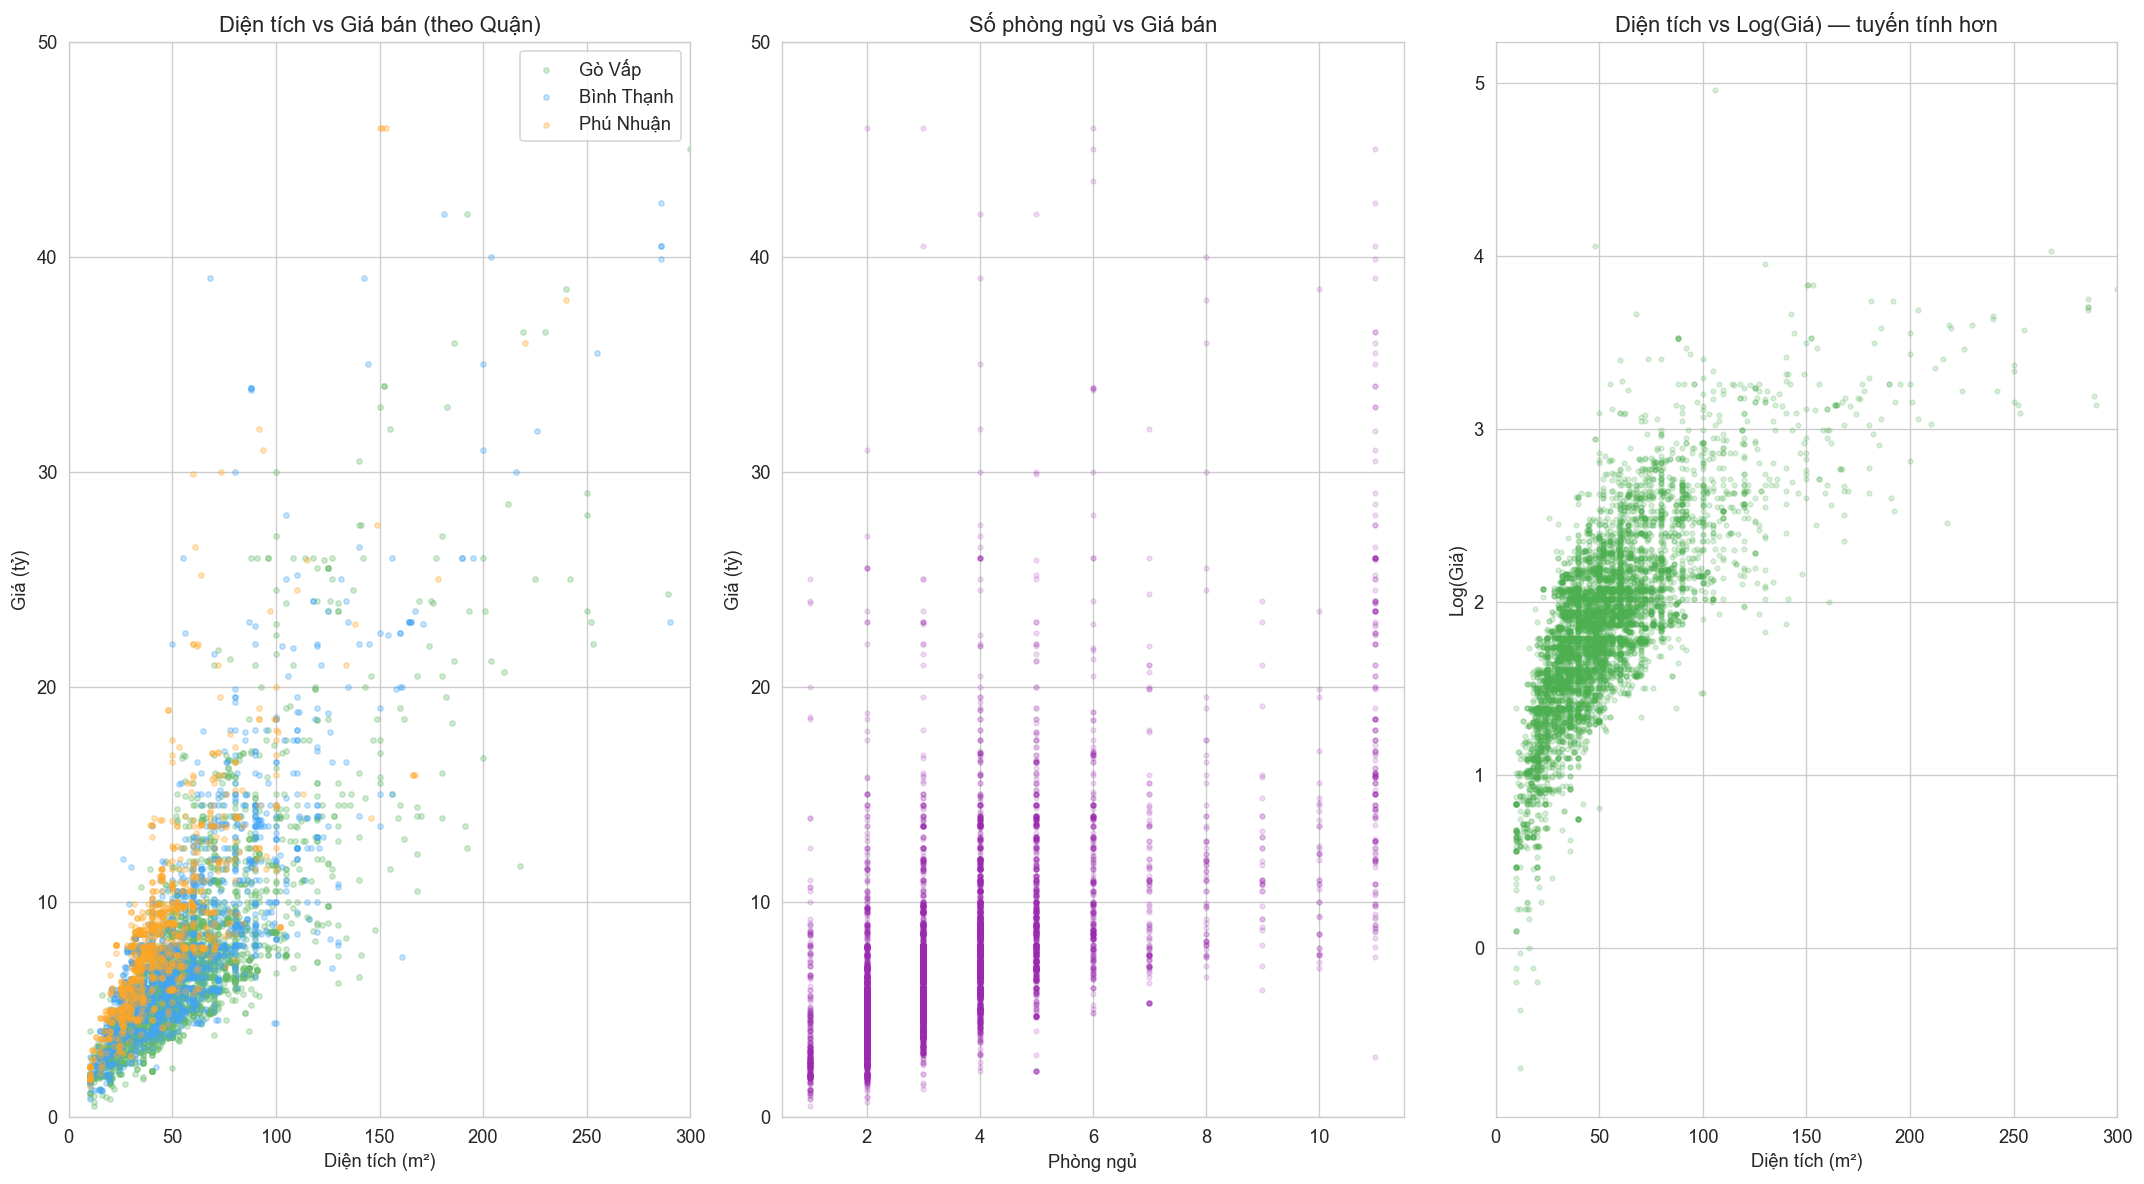

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 10))

# Diện tích vs Giá — theo quận
for q, color in zip(["Gò Vấp","Bình Thạnh","Phú Nhuận"], ["#66BB6A","#42A5F5","#FFA726"]):
    mask = df["quan"] == q
    axes[0].scatter(df.loc[mask,"dien_tich"], df.loc[mask,"gia_ban"],
                       alpha=0.3, s=10, label=q, color=color)
axes[0].set_title("Diện tích vs Giá bán (theo Quận)")
axes[0].set_xlabel("Diện tích (m²)")
axes[0].set_ylabel("Giá (tỷ)")
axes[0].set_xlim(0, 300)
axes[0].set_ylim(0, 50)
axes[0].legend()

axes[1].scatter(df["so_phong_ngu"], df["gia_ban"], alpha=0.15, s=8, color="#9C27B0")
axes[1].set_title("Số phòng ngủ vs Giá bán")
axes[1].set_xlabel("Phòng ngủ")
axes[1].set_ylabel("Giá (tỷ)")
axes[1].set_ylim(0, 50)

# Diện tích vs Log(Giá)
axes[2].scatter(df["dien_tich"], df["log_gia_ban"], alpha=0.2, s=8, color="#4CAF50")
axes[2].set_title("Diện tích vs Log(Giá) — tuyến tính hơn")
axes[2].set_xlabel("Diện tích (m²)")
axes[2].set_ylabel("Log(Giá)")
axes[2].set_xlim(0, 300)

plt.tight_layout()
plt.show()

**Nhận xét:**
- Diện tích vs Giá: tương quan dương rõ ràng. Phú Nhuận đắt hơn cùng diện tích.
- **`hem_width`** vs Giá: tương quan rất mạnh — hẻm càng rộng (6m, 8m) giá càng cao.
- Log(Giá) vs Diện tích tuyến tính hơn → xác nhận nên dùng `log_gia_ban` làm target.

## 8. Correlation Heatmap & Multicollinearity


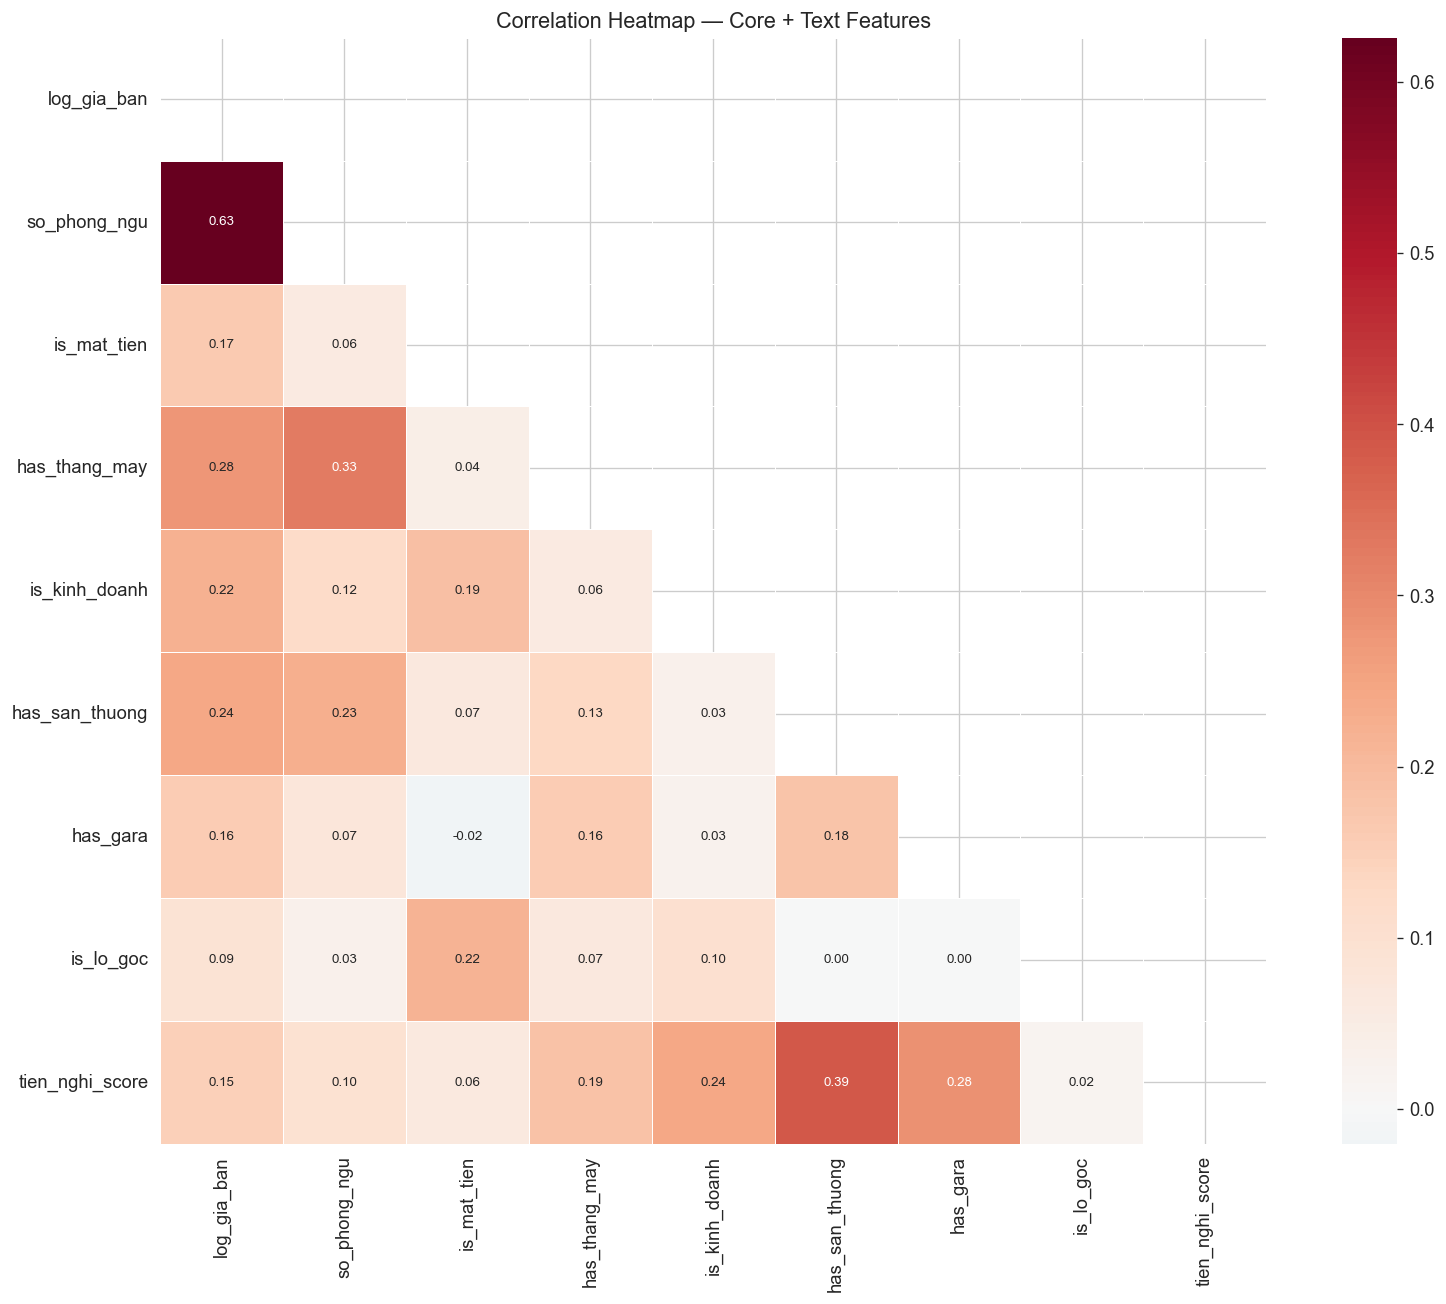

In [12]:
# Chọn features chính (KHÔNG gồm gia_m2 — leakage cho bài toán prediction)
core_num = ["log_gia_ban", "dien_tich_dat", "chieu_ngang", "chieu_dai",
            "so_phong_ngu", "so_phong_ve_sinh", "tong_so_tang", "gia_m2",
            "aspect_ratio", "dien_tich_san_total"]
core_num = [c for c in core_num if c in df.columns]

# Thêm text features có corr cao
text_high = ["is_mat_tien", "has_thang_may", "is_kinh_doanh", "has_san_thuong",
             "has_gara", "is_lo_goc", "hem_width", "tien_nghi_score"]
text_high = [c for c in text_high if c in df.columns]

all_cols = core_num + text_high
corr = df[all_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlation Heatmap — Core + Text Features", fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# Top correlation with target
print("Correlation với log_gia_ban (tất cả numeric features):")
all_numeric = df.select_dtypes(include='number').columns
corr_target = df[all_numeric].corr()["log_gia_ban"].drop("log_gia_ban", errors='ignore').sort_values(ascending=False)

for feat, val in corr_target.head(20).items():
    bar = "█" * int(abs(val) * 30)
    print(f"  {feat:28s} {val:+.3f}  {bar}")

print(f"\n... (showing top 20 of {len(corr_target)})")

Correlation với log_gia_ban (tất cả numeric features):
  gia_ban                      +0.853  █████████████████████████
  dien_tich                    +0.732  █████████████████████
  so_phong_ngu                 +0.626  ██████████████████
  has_thang_may                +0.279  ████████
  gia_kv_mean                  +0.277  ████████
  has_san_thuong               +0.243  ███████
  is_dong_tien                 +0.239  ███████
  gia_kv_hien_tai              +0.237  ███████
  is_kinh_doanh                +0.220  ██████
  is_mat_tien                  +0.166  ████
  has_gara                     +0.157  ████
  tien_nghi_score              +0.149  ████
  is_lo_goc                    +0.091  ██
  is_hxh                       +0.075  ██
  is_nha_nat                   +0.075  ██
  is_ban_gap                   +0.070  ██
  is_no_hau                    +0.061  █
  gia_kv_volatility            +0.055  █
  is_ngop_bank                 +0.044  █
  is_chinh_chu                 +0.039  █

... (showing 

In [14]:
# Kiểm tra multicollinearity — cặp features |corr| > 0.7
print("Các cặp feature tương quan cao (|r| > 0.65):")
print(f"{'Feature 1':28s} {'Feature 2':28s} {'Corr':>8s}  Note")
print("-" * 85)

feat_cols = [c for c in all_numeric if c not in ["gia_ban","log_gia_ban","gia_m2"]]
corr_matrix = df[feat_cols].corr()
pairs = []
for i in range(len(feat_cols)):
    for j in range(i+1, len(feat_cols)):
        c = corr_matrix.iloc[i,j]
        if abs(c) > 0.65:
            pairs.append((feat_cols[i], feat_cols[j], c))

pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for f1, f2, c in pairs:
    note = "⚠️ Cân nhắc drop 1" if abs(c) > 0.75 else "📋 Theo dõi"
    print(f"  {f1:26s} {f2:26s} {c:+8.3f}  {note}")

Các cặp feature tương quan cao (|r| > 0.65):
Feature 1                    Feature 2                        Corr  Note
-------------------------------------------------------------------------------------
  gia_kv_hien_tai            gia_kv_mean                  +0.903  ⚠️ Cân nhắc drop 1


**Nhận xét Multicollinearity:**
- `gia_kv_hien_tai` ↔ `gia_kv_mean` (corr = +0.903): Cân nhắc drop 1 cho mô hình tuyến tính
- Tree-based models xử lý tốt multicollinearity → giữ cả hai
- Không có cặp nào khác vượt |r| > 0.65


## 9.  Phát hiện Outlier (IQR Method)


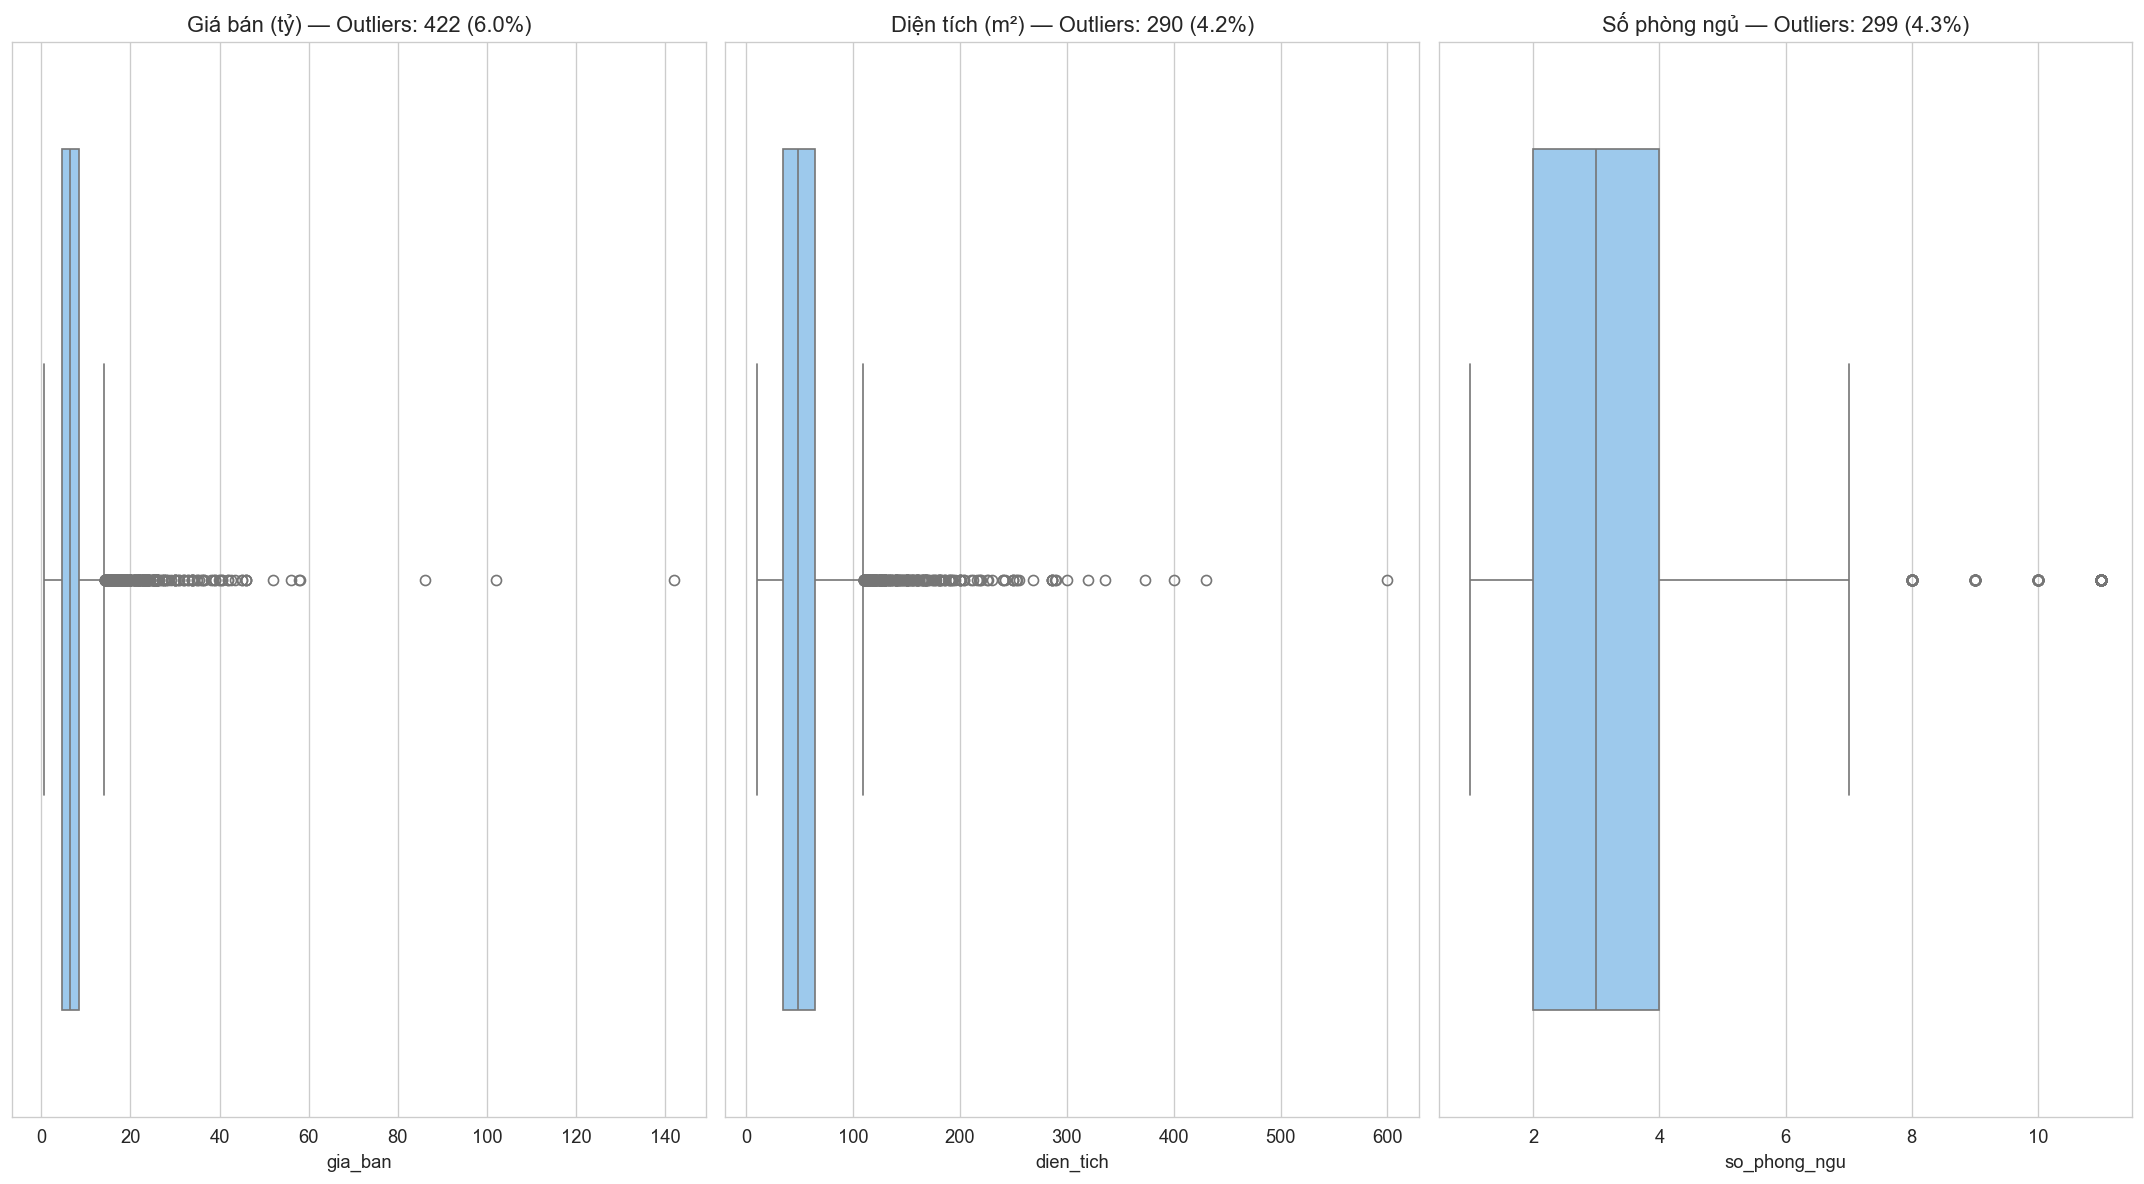

       Feature   Q1   Q3 Lower Upper  N_outliers  Pct
  Giá bán (tỷ)  4.8  8.5   0.0  14.1         422 6.0%
Diện tích (m²) 34.0 64.0   0.0 109.0         290 4.2%
  Số phòng ngủ  2.0  4.0   0.0   7.0         299 4.3%


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 10))

outlier_summary = []
for ax, col, title in zip(axes.flat,
    ["gia_ban","dien_tich","so_phong_ngu"],
    ["Giá bán (tỷ)","Diện tích (m²)","Số phòng ngủ"]):

    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((data < lower) | (data > upper)).sum()
    pct = n_out / len(data) * 100

    outlier_summary.append({"Feature": title, "Q1": f"{Q1:.1f}", "Q3": f"{Q3:.1f}",
                            "Lower": f"{max(lower,0):.1f}", "Upper": f"{upper:.1f}",
                            "N_outliers": n_out, "Pct": f"{pct:.1f}%"})

    sns.boxplot(x=data, ax=ax, color="#90CAF9")
    ax.set_title(f"{title} — Outliers: {n_out} ({pct:.1f}%)")

plt.tight_layout()
plt.show()

print(pd.DataFrame(outlier_summary).to_string(index=False))

**Nhận xét:**
- **Giá bán**: 422 outlier (6.0%) — Q1=4.8, Q3=8.5, upper=14.1 tỷ
- **Diện tích**: 290 outlier (4.2%) — Q1=34, Q3=64, upper=109 m²
- **Số phòng ngủ**: 299 outlier (4.3%) — Q1=2, Q3=4, upper=7

Strategy: Dùng `log_gia_ban` để giảm ảnh hưởng outlier. Các outlier giá chủ yếu là nhà mặt tiền/biệt thự, không nên xóa.


## 10. Missing Values


In [16]:
fig, ax = plt.subplots(figsize=(12, 8))

miss = df.select_dtypes(include='number').isnull().sum().sort_values(ascending=True)
miss = miss[miss > 0]

if len(miss) == 0:
    print("Không có missing values nào trong numeric features.")
    plt.close(fig)
else:
    colors = ['#F44336' if v > len(df)*0.4 else '#FF9800' if v > len(df)*0.2 else '#4CAF50' for v in miss.values]

    miss.plot.barh(ax=ax, color=colors)
    ax.set_title("Missing Values — Numeric Columns")
    ax.set_xlabel("Số lượng missing")

    for i, (v, col) in enumerate(zip(miss.values, miss.index)):
        ax.text(v + 30, i, f"{v/len(df)*100:.1f}%", va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print("Legend: 🟢 <20% (impute ok) | 🟠 20-40% (cẩn thận) | 🔴 >40% (flag/drop)")

Không có missing values nào trong numeric features.


## 10A. Violin Plot — Giá theo Quận × Loại hình

Phân tích tương tác giữa **Quận** và **Loại hình** để thấy phân phối giá chi tiết hơn boxplot.

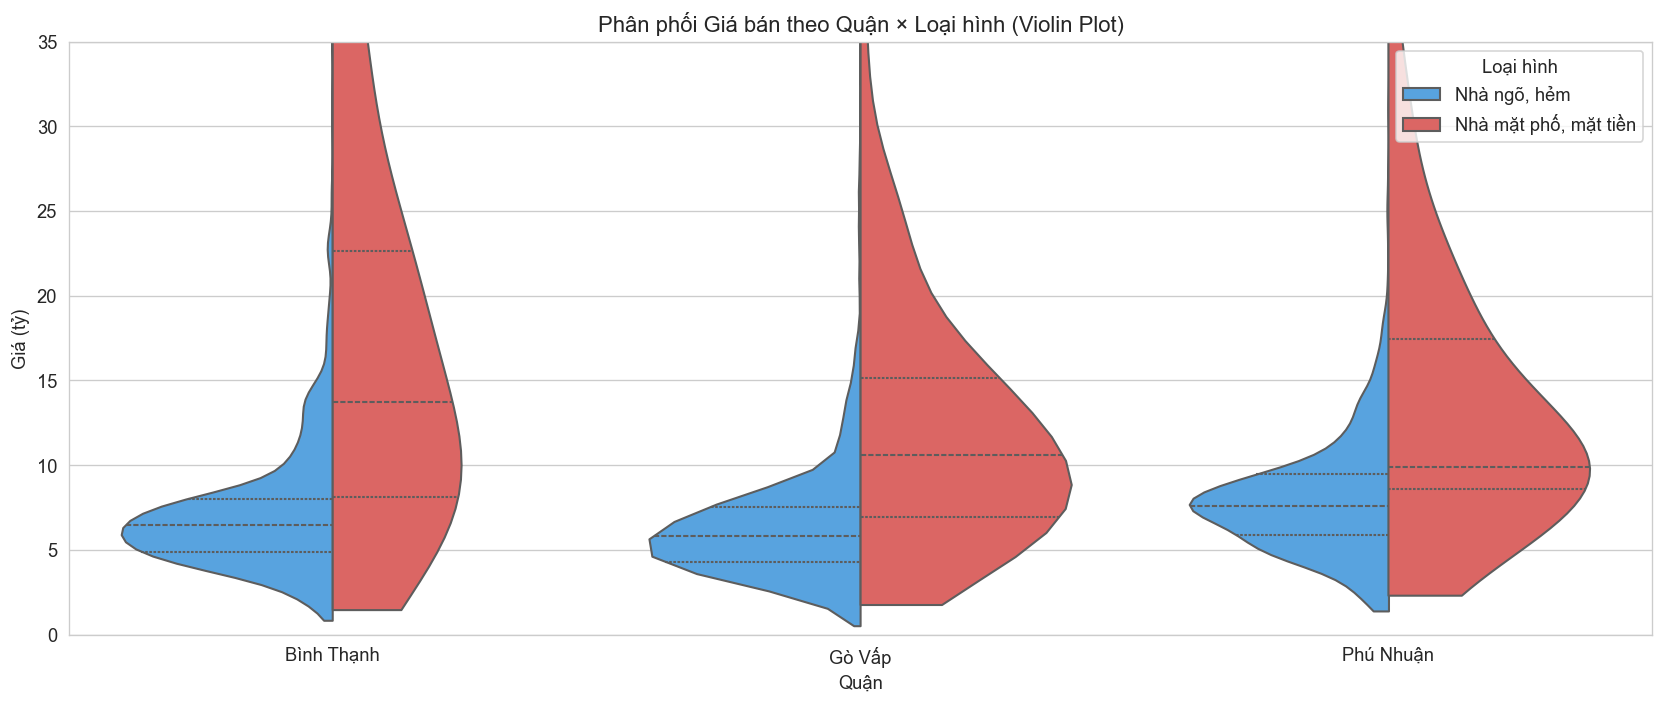

Median giá (tỷ) theo Quận × Loại hình:
                          median                              count             
loai_hinh  Nhà mặt phố, mặt tiền Nhà ngõ, hẻm Nhà mặt phố, mặt tiền Nhà ngõ, hẻm
quan                                                                            
Bình Thạnh                 13.75         6.45                    84         2184
Gò Vấp                     10.60         5.80                   288         3414
Phú Nhuận                   9.90         7.60                    74          935


In [17]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.violinplot(x="quan", y="gia_ban", hue="loai_hinh", data=df, split=True,
               palette={"Nhà ngõ, hẻm": "#42A5F5", "Nhà mặt phố, mặt tiền": "#EF5350"},
               inner="quart", ax=ax, cut=0)
ax.set_ylim(0, 35)
ax.set_title("Phân phối Giá bán theo Quận × Loại hình (Violin Plot)")
ax.set_ylabel("Giá (tỷ)")
ax.set_xlabel("Quận")
ax.legend(title="Loại hình", loc="upper right")
plt.tight_layout()
plt.show()

# Thống kê chi tiết
print("Median giá (tỷ) theo Quận × Loại hình:")
pivot = df.pivot_table(values="gia_ban", index="quan", columns="loai_hinh",
                       aggfunc=["median","count"])
print(pivot.to_string())

**Nhận xét:**
- Nhà mặt phố luôn đắt hơn nhà hẻm ở cả 3 quận, nhưng mức chênh khác nhau.
- Phú Nhuận có median cao nhất ở cả 2 loại hình — phản ánh vị trí trung tâm.
- Violin plot cho thấy nhà hẻm có phân phối tập trung hơn, mặt phố phân tán rộng.

## 10B. Tiện nghi Score vs Giá bán

`tien_nghi_score` tổng hợp các tiện nghi (thang máy, sân thượng, gara...). Phân tích mối quan hệ với giá.

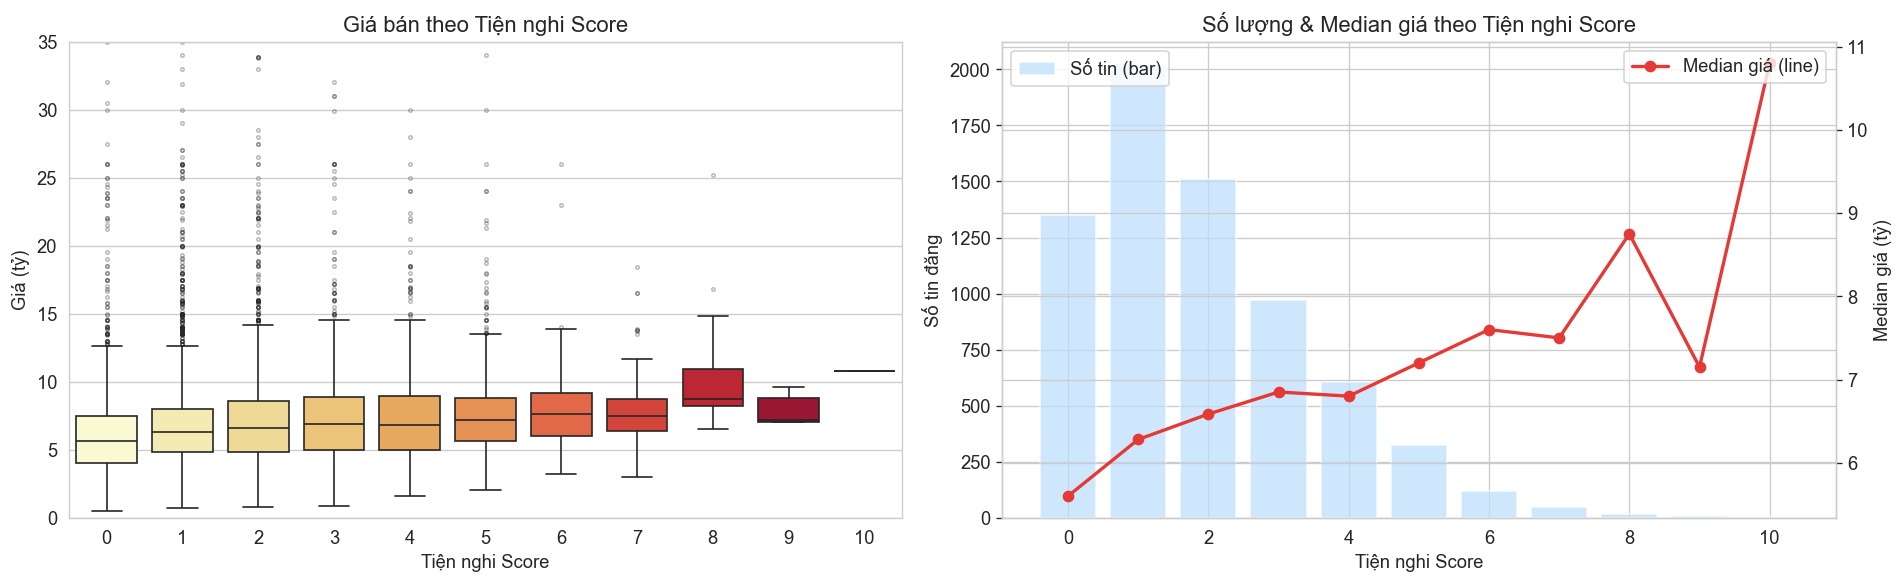

Correlation tien_nghi_score <-> log_gia_ban: +0.149

Median giá theo score:
  Score  0: median = 5.6 tỷ  (n=1351)
  Score  1: median = 6.3 tỷ  (n=2023)
  Score  2: median = 6.6 tỷ  (n=1512)
  Score  3: median = 6.8 tỷ  (n=973)
  Score  4: median = 6.8 tỷ  (n=604)
  Score  5: median = 7.2 tỷ  (n=326)
  Score  6: median = 7.6 tỷ  (n=117)
  Score  7: median = 7.5 tỷ  (n=49)
  Score  8: median = 8.8 tỷ  (n=17)
  Score  9: median = 7.2 tỷ  (n=6)
  Score 10: median = 10.8 tỷ  (n=1)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot theo tien nghi score
score_order = sorted(df["tien_nghi_score"].dropna().unique())
sns.boxplot(x="tien_nghi_score", y="gia_ban", data=df, order=score_order,
            ax=axes[0], palette="YlOrRd", hue="tien_nghi_score", legend=False,
            flierprops=dict(marker="o", markersize=2, alpha=0.3))
axes[0].set_ylim(0, 35)
axes[0].set_title("Giá bán theo Tiện nghi Score")
axes[0].set_xlabel("Tiện nghi Score")
axes[0].set_ylabel("Giá (tỷ)")

# Median gia theo score — line plot
median_by_score = df.groupby("tien_nghi_score")["gia_ban"].agg(["median","count"])
ax2 = axes[1]
ax2.bar(median_by_score.index, median_by_score["count"], color="#BBDEFB", alpha=0.7, label="Số tin (bar)")
ax2_twin = ax2.twinx()
ax2_twin.plot(median_by_score.index, median_by_score["median"], color="#E53935",
              marker="o", linewidth=2, label="Median giá (line)")
ax2.set_xlabel("Tiện nghi Score")
ax2.set_ylabel("Số tin đăng")
ax2_twin.set_ylabel("Median giá (tỷ)")
ax2.set_title("Số lượng & Median giá theo Tiện nghi Score")
ax2.legend(loc="upper left")
ax2_twin.legend(loc="upper right")

plt.tight_layout()
plt.show()

corr_val = df[["tien_nghi_score","log_gia_ban"]].corr().iloc[0,1]
print(f"Correlation tien_nghi_score <-> log_gia_ban: {corr_val:+.3f}")
print(f"\nMedian giá theo score:")
for score, row in median_by_score.iterrows():
    print(f"  Score {score:2.0f}: median = {row['median']:.1f} tỷ  (n={row['count']:.0f})")

**Nhận xét:**
- Giá tăng rõ rệt khi tiện nghi score tăng — đặc biệt từ score 3 trở lên.
- Score 0-2 chiếm đa số (nhà phổ thông), score ≥5 rất ít nhưng giá cao vượt trội.
- Đây là feature tổng hợp hữu ích cho mô hình, tránh multicollinearity từ nhiều binary features riêng lẻ.

## 10C. Feature Interaction — Text Features theo Quận

So sánh tỷ lệ và ảnh hưởng của các text features chính giữa các quận.

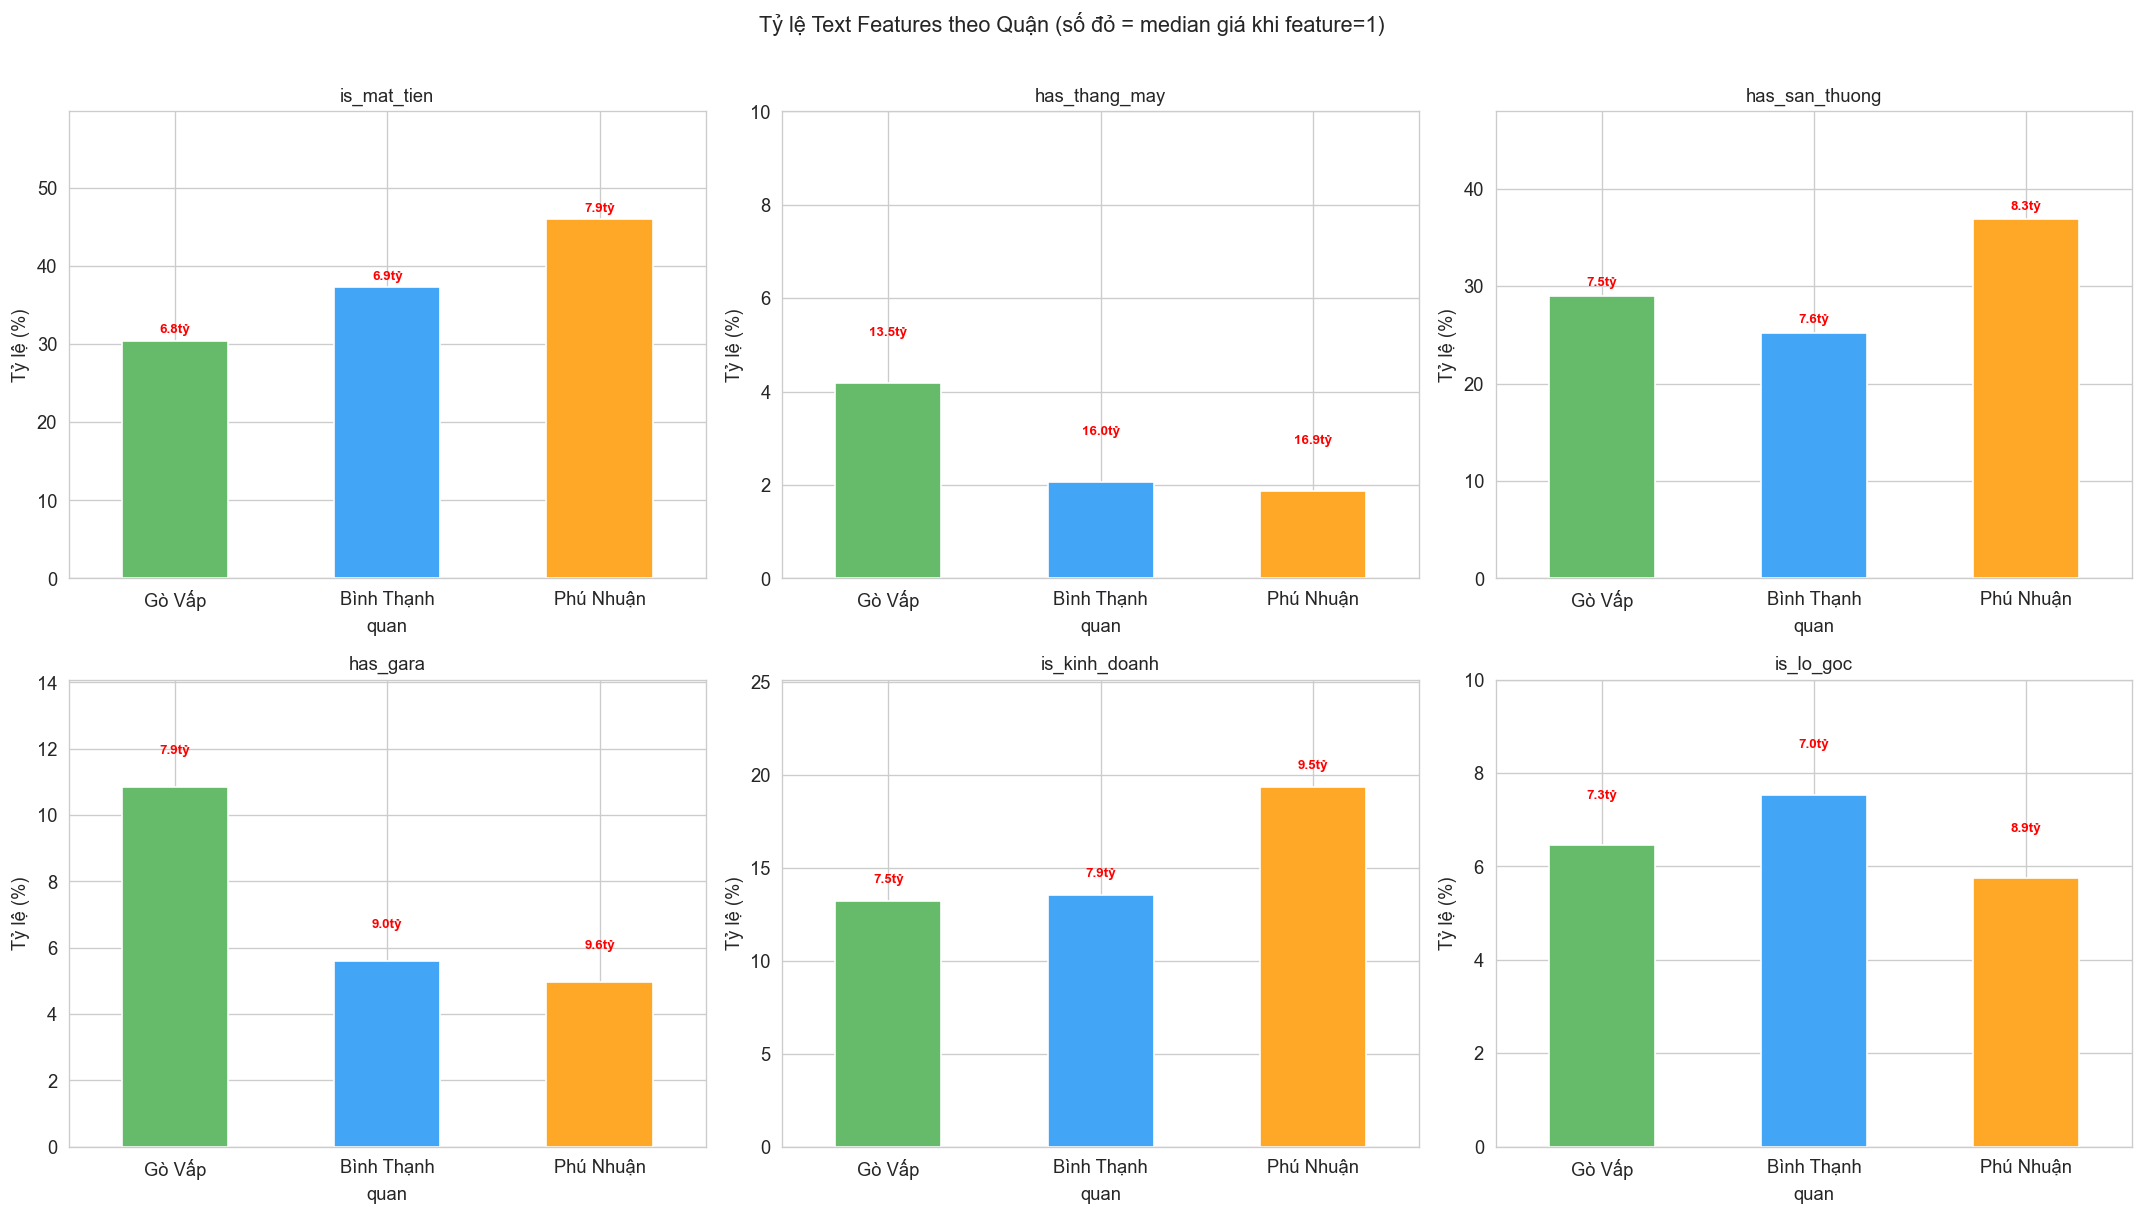

In [19]:
# Ty le text features theo quan
key_text = ["is_mat_tien", "has_thang_may", "has_san_thuong", "has_gara",
            "is_kinh_doanh", "is_lo_goc"]
key_text = [f for f in key_text if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feat in zip(axes.flat, key_text):
    pivot = df.groupby("quan")[feat].mean() * 100
    colors = ["#66BB6A", "#42A5F5", "#FFA726"]
    pivot.reindex(["Gò Vấp", "Bình Thạnh", "Phú Nhuận"]).plot.bar(
        ax=ax, color=colors, edgecolor="white")

    # Them median gia khi feature=1 cho moi quan
    for i, quan in enumerate(["Gò Vấp", "Bình Thạnh", "Phú Nhuận"]):
        subset = df[(df["quan"] == quan) & (df[feat] == 1)]
        if len(subset) > 0:
            med = subset["gia_ban"].median()
            ax.text(i, pivot.get(quan, 0) + 1, f"{med:.1f}tỷ", ha="center",
                    fontsize=8, color="red", fontweight="bold")

    ax.set_title(f"{feat}", fontsize=11)
    ax.set_ylabel("Tỷ lệ (%)")
    ax.tick_params(axis="x", rotation=0)
    ax.set_ylim(0, max(pivot.max() * 1.3, 10))

for j in range(len(key_text), 6):
    axes.flat[j].set_visible(False)

plt.suptitle("Tỷ lệ Text Features theo Quận (số đỏ = median giá khi feature=1)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Nhận xét:**
- Phú Nhuận có tỷ lệ `is_mat_tien` cao hơn → nhiều nhà mặt tiền hơn, góp phần giá cao.
- `has_thang_may` và `has_san_thuong` phân bố tương đối đều giữa các quận.
- Median giá khi feature=1 luôn cao hơn ở Phú Nhuận, khẳng định hiệu ứng vị trí cộng dồn.

## 10D. Phân khúc Giá (Price Segmentation)

Chia giá bán thành các phân khúc để hiểu cấu trúc thị trường.

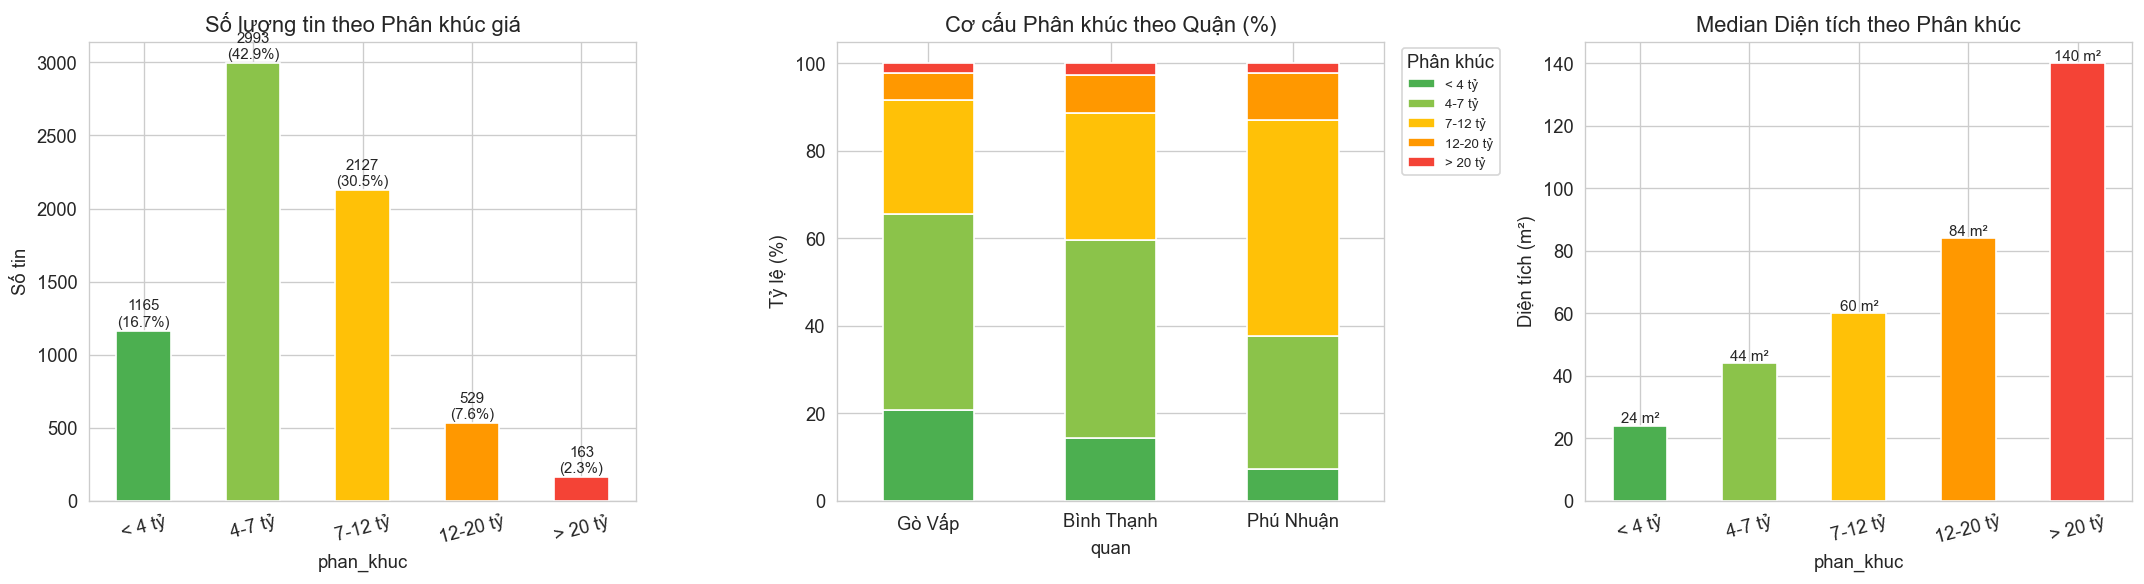

In [20]:
# Tao phan khuc gia
bins = [0, 4, 7, 12, 20, 100]
labels = ["< 4 tỷ", "4-7 tỷ", "7-12 tỷ", "12-20 tỷ", "> 20 tỷ"]
df["phan_khuc"] = pd.cut(df["gia_ban"], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Phan bo phan khuc
colors_seg = ["#4CAF50", "#8BC34A", "#FFC107", "#FF9800", "#F44336"]
counts = df["phan_khuc"].value_counts().reindex(labels)
counts.plot.bar(ax=axes[0], color=colors_seg, edgecolor="white")
axes[0].set_title("Số lượng tin theo Phân khúc giá")
axes[0].set_ylabel("Số tin")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)

# 2. Phan khuc theo Quan (stacked bar)
ct = pd.crosstab(df["quan"], df["phan_khuc"], normalize="index") * 100
ct = ct.reindex(columns=labels)
ct.reindex(["Gò Vấp", "Bình Thạnh", "Phú Nhuận"]).plot.bar(
    stacked=True, ax=axes[1], color=colors_seg, edgecolor="white")
axes[1].set_title("Cơ cấu Phân khúc theo Quận (%)")
axes[1].set_ylabel("Tỷ lệ (%)")
axes[1].legend(title="Phân khúc", bbox_to_anchor=(1.02, 1), fontsize=8)
axes[1].tick_params(axis="x", rotation=0)

# 3. Dien tich trung binh theo phan khuc
median_dt = df.groupby("phan_khuc", observed=True)["dien_tich"].median().reindex(labels)
median_dt.plot.bar(ax=axes[2], color=colors_seg, edgecolor="white")
axes[2].set_title("Median Diện tích theo Phân khúc")
axes[2].set_ylabel("Diện tích (m²)")
axes[2].tick_params(axis="x", rotation=15)
for i, v in enumerate(median_dt.values):
    axes[2].text(i, v + 1, f"{v:.0f} m²", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# Cleanup
df.drop(columns=["phan_khuc"], inplace=True)

**Nhận xét:**
- Phân khúc **4-7 tỷ** chiếm đa số → thị trường nhà phổ thông.
- Gò Vấp tập trung ở phân khúc thấp, Phú Nhuận có tỷ lệ phân khúc cao nhất.
- Diện tích tăng dần theo phân khúc — diện tích là yếu tố quyết định giá chính.

## 10E. Pairplot — Top Features vs Log(Giá)

Trực quan hóa mối quan hệ giữa các features quan trọng nhất.

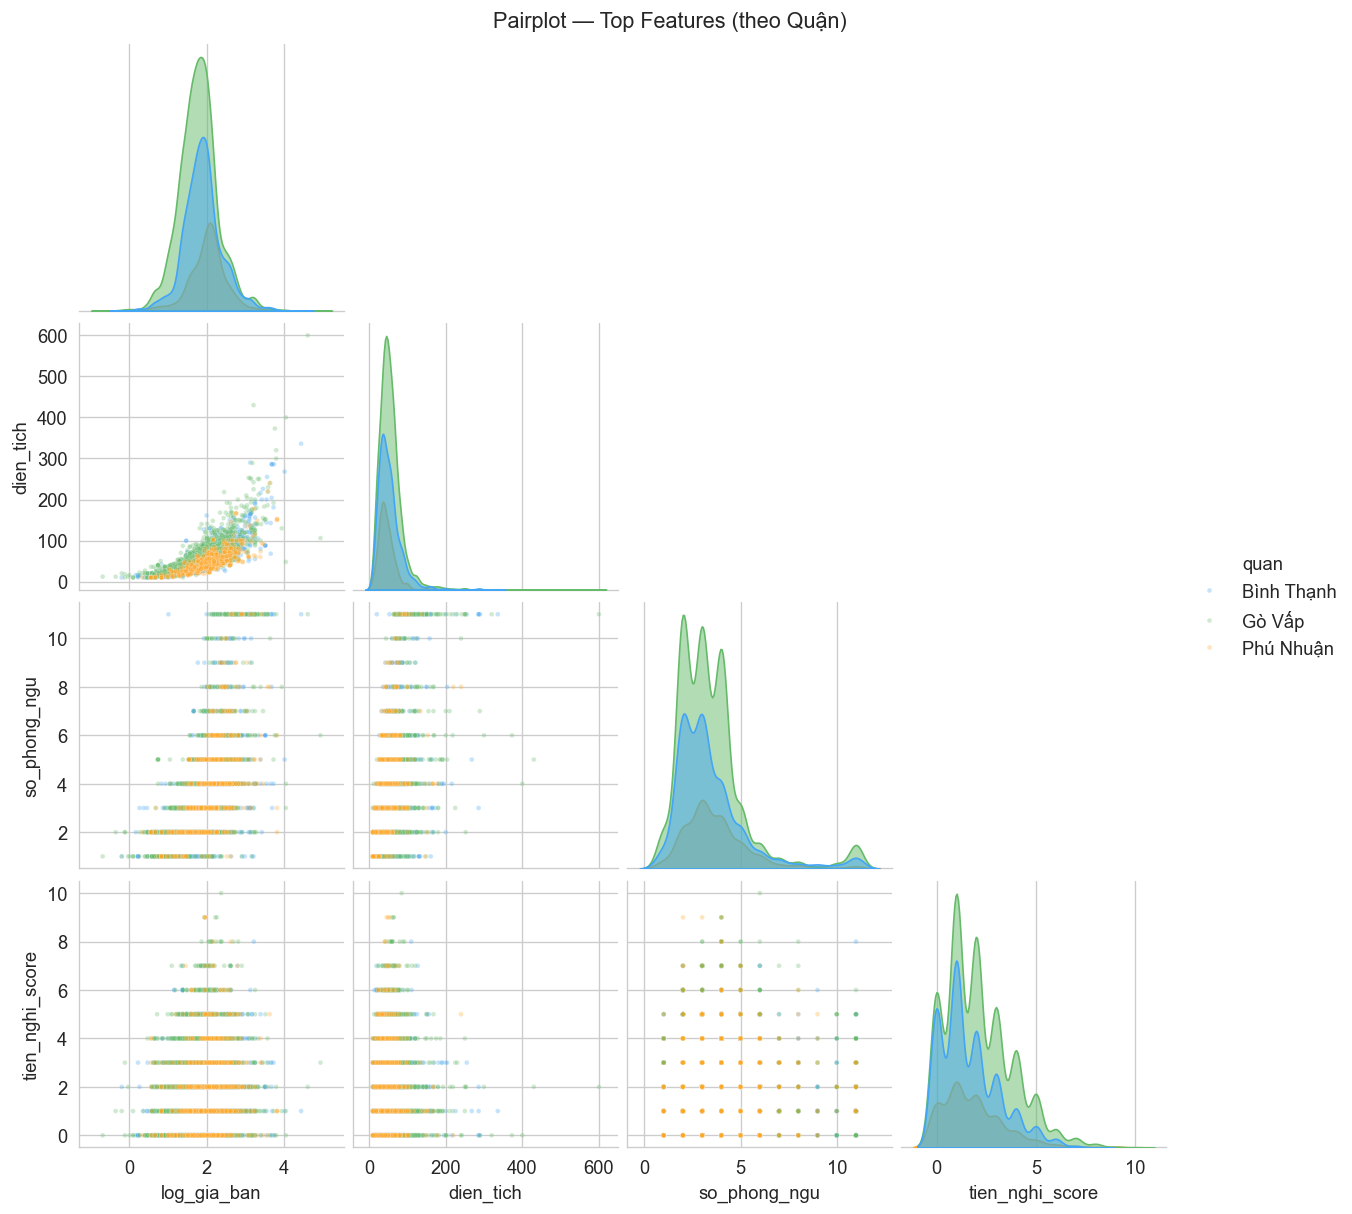

In [21]:
# Pairplot top 4 features vs target
pair_cols = ["log_gia_ban", "dien_tich", "so_phong_ngu", "tien_nghi_score"]
pair_cols = [c for c in pair_cols if c in df.columns]

g = sns.pairplot(df[pair_cols + ["quan"]].dropna(), hue="quan",
                 palette={"Gò Vấp": "#66BB6A", "Bình Thạnh": "#42A5F5", "Phú Nhuận": "#FFA726"},
                 plot_kws={"alpha": 0.3, "s": 8},
                 diag_kws={"alpha": 0.5},
                 height=2.5, corner=True)
g.fig.suptitle("Pairplot — Top Features (theo Quận)", y=1.01, fontsize=13)
plt.show()

**Nhận xét:**
- `dien_tich` vs `log_gia_ban`: tương quan tuyến tính rõ, Phú Nhuận có slope cao hơn.
- `so_phong_ngu` vs `dien_tich`: tương quan dương mạnh (nhà lớn = nhiều phòng).
- Pairplot xác nhận Phú Nhuận luôn ở dải giá cao hơn cùng diện tích / số phòng.

## 11. Tổng hợp Insights

### Target
- Dùng `log_gia_ban` (skewness = 0.26) thay vì `gia_ban` (skewness = 6.49)

### Top Features (corr với log_gia_ban)
1. `dien_tich` (+0.732) — quan trọng nhất
2. `so_phong_ngu` (+0.626)
3. `has_thang_may` (+0.279), `gia_kv_mean` (+0.277)
4. `has_san_thuong` (+0.243), `is_dong_tien` (+0.239)

### Multicollinearity
- Chỉ `gia_kv_hien_tai` ↔ `gia_kv_mean` (r=+0.903) cần lưu ý

### Anomaly Detection Signals
- `is_ban_gap`, `is_ngop_bank` — tín hiệu bán gấp/ngộp
- Residual từ prediction model → residual_z score

---

## Kết luận

### 1. Phân phối giá nhà
- Giá bán lệch phải mạnh (mean=7.42 tỷ, median=6.48 tỷ, skewness=6.49)
- `log_gia_ban` giúp phân phối gần chuẩn (skewness=0.26)

### 2. Các yếu tố ảnh hưởng giá nhà
- **Diện tích** (corr = +0.732): Yếu tố quyết định số 1
- **Số phòng ngủ** (corr = +0.626): Phản ánh quy mô căn nhà
- **Vị trí**: Phú Nhuận đắt nhất (7.85 tỷ), Gò Vấp rẻ nhất (5.95 tỷ)
- **Thang máy** tạo chênh lệch giá lớn nhất (+7.5 tỷ)

### 3. Outlier
- Giá: 422 (6.0%), Diện tích: 290 (4.2%), Phòng: 299 (4.3%)
- Dùng log transform thay vì loại bỏ

### 4. Định hướng Modeling
- **Regression**: Target = `log_gia_ban`, 26 features
- **Anomaly Detection**: residual + `is_ban_gap`, `is_ngop_bank`

### 5. Hạn chế
- Dữ liệu chỉ 3 quận (Gò Vấp 53%, Bình Thạnh 32.5%, Phú Nhuận 14.5%)
- Thiếu thông tin: năm xây dựng, số tầng, diện tích sử dụng


### Interaction & Segmentation (bổ sung)
- Violin plot: mặt phố luôn đắt hơn hẻm, Phú Nhuận dẫn đầu cả 2 loại hình
- `tien_nghi_score`: tương quan dương rõ rệt — feature tổng hợp tốt
- Phân khúc 4-7 tỷ chiếm đa số → thị trường nhà phổ thông TP.HCM
- Pairplot xác nhận `dien_tich` là predictor mạnh nhất, hiệu ứng quận rõ ràng